In [1]:
import os
import glob
import random
import re
import shutil
import time
from argparse import Namespace
from functools import partial
from multiprocessing import Pool
from numbers import Number
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nibabel as nib
import kagglehub

from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.amp import GradScaler, autocast

from tqdm import tqdm
import copy

In [2]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False


def mean_absolute_error(preds: Tensor, targets: Tensor) -> float:
    """Compute the mean absolute error between predictions and targets"""
    return (preds.view(-1) - targets.view(-1)).abs().mean().item()

class TensorboardLogger(SummaryWriter):
    def __init__(
        self,
        log_dir: str = None,
        config: Namespace = None,
        enabled: bool = True,
        comment: str = '',
        purge_step: int = None,
        max_queue: int = 10,
        flush_secs: int = 120,
        filename_suffix: str = ''
    ):
        self.enabled = enabled
        if self.enabled:
            super().__init__(
                log_dir=log_dir,
                comment=comment,
                purge_step=purge_step,
                max_queue=max_queue,
                flush_secs=flush_secs,
                filename_suffix=filename_suffix
            )
        else:
            return

        if config is not None:
            self.add_hparams(
                {k: v for k, v in vars(config).items() if isinstance(
                    v, (int, float, str, bool, torch.Tensor))},
                {}
            )

    def log(self, data: Dict[str, Any], step: int) -> None:
        """Log each entry in data as its corresponding data type"""
        if self.enabled:
            for k, v in data.items():
                if isinstance(v, Number):
                    self.add_scalar(k, v, step)

                elif (isinstance(v, np.ndarray) or isinstance(v, torch.Tensor)) and len(v.shape) >= 3:
                    if len(v.shape) == 3:
                        self.add_image(k, v, step)
                    elif len(v.shape) == 4:
                        self.add_images(k, v, step)
                    else:
                        raise ValueError(f'Unsupported image shape: {v.shape}')
                    
                elif isinstance(v, plt.Figure):
                    self.add_figure(k, v, step)
                else:
                    raise ValueError(f'Unsupported data type: {type(v)}')
                
def load_nii(path: str, dtype: str = 'float32') -> np.ndarray:
    """Load an MRI scan from disk and convert it to a given datatype

    :param path: Path to file
    :param dtype: Target dtype
    :return img: Loaded image. Shape (H, W, D)
    """
    return nib.load(path).get_fdata().astype(np.dtype(dtype))

def load_segmentations(paths: str):
    """Load all segmentations and associated subject_ids"""
    filenames, segmentations = [], []
    for im in tqdm(paths):
        id = im.split('_brain_')[0].split('/')[-1].split('-')[1].split('_')[0]
        segmentations.append(load_nii(im))
        filenames.append(id)
    return filenames, np.array(segmentations)

def plot_segmentations(im: np.ndarray, seg: np.ndarray, i: int = 65, title: str = None):
    fig, ax = plt.subplots(2, 3, figsize=(20, 10))

    col = 2
    ax[0, col].imshow(np.rot90(im[..., i], k=3), cmap='gray')
    ax[0, col].imshow(np.rot90(seg[..., i], k=3),
                 alpha=0.5 * (np.rot90(seg[..., i] > 0, k=3)),
                 interpolation=None, cmap='jet')
    ax[1, col].imshow(np.rot90(im[..., i], k=3), cmap='gray')
    ax[0, col].set_title('Axial')

    k = 1
    col = 0
    ax[0, col].imshow(np.rot90(im[i, ...], k=k), cmap='gray')
    ax[0, col].imshow(np.rot90(seg[i, ...], k=k),
                 alpha=0.5 * (np.rot90(seg[i, ...] > 0, k=k)),
                 interpolation=None, cmap='jet')
    ax[1, col].imshow(np.rot90(im[i, ...], k=k), cmap='gray')
    ax[0, col].set_title('Sagittal')

    col = 1
    ax[0, col].imshow(np.rot90(im[:, i, :], k=k), cmap='gray')
    ax[0, col].imshow(np.rot90(seg[:, i, :], k=k),
                 alpha=0.5 * (np.rot90(seg[:, i, :] > 0, k=k)),
                 interpolation=None, cmap='jet')
    ax[1, col].imshow(np.rot90(im[:, i, :], k=k), cmap='gray')
    ax[0, col].set_title('Coronal')

    if title is not None:
        # plt.set_title(title)
        fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()

# Load dataset

In [3]:
KAGGLE_DATASET_HANDLE = 'hamedamin/preprocessed-oasis-and-epilepsy-and-ixi'

def _check_kaggle_credentials() -> None:
    has_env = bool(os.environ.get('KAGGLE_USERNAME')) and bool(os.environ.get('KAGGLE_KEY'))
    if not has_env:
        kaggle_src = Path('./kaggle.json')
        if kaggle_src.exists():
            kaggle_dst = Path.home() / '.kaggle' / 'kaggle.json'
            kaggle_dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy(kaggle_src, kaggle_dst)
            kaggle_dst.chmod(0o600)
        else:
            print("[warning] Kaggle credentials not found.")

_check_kaggle_credentials()
DATA_ROOT = kagglehub.dataset_download(KAGGLE_DATASET_HANDLE)
print(f"✓ Dataset downloaded.")

✓ Dataset downloaded.


In [4]:
T1_PATTERNS = ['**/wm[Ii][Xx][Ii]*.nii*']   
GM_PATTERNS = ['**/mwp1*.nii*']             
WM_PATTERNS = ['**/mwp2*.nii*']              

_IXI_ID_RE = re.compile(r'(IXI\d+)', re.IGNORECASE)

def _first_match(root: str, patterns: List[str]) -> List[str]:
    found = []
    for pat in patterns:
        found.extend(glob.glob(os.path.join(root, pat), recursive=True))
    return sorted(set(found))

def discover_subjects(root: str) -> List[Dict[str, str]]:
    """Find matching (T1, GM-prob, WM-prob) triplets per subject."""
    t1_files = _first_match(root, T1_PATTERNS)
    gm_files = _first_match(root, GM_PATTERNS)
    wm_files = _first_match(root, WM_PATTERNS)

    if not (t1_files and gm_files and wm_files):
        raise FileNotFoundError(
            f"Could not find T1/GM/WM files under '{root}'.\n"
            f"  T1={len(t1_files)}, GM={len(gm_files)}, WM={len(wm_files)}"
        )

    def subj_key(path: str) -> str:
        base = os.path.basename(path)
        m = _IXI_ID_RE.search(base)
        if m:
            return m.group(1).upper()
        for prefix in ('mwp1', 'mwp2', 'wm'):
            if base.startswith(prefix):
                base = base[len(prefix):]
        return base.split('.')[0]

    gm_by_subj  = {subj_key(p): p for p in gm_files}
    wm_by_subj  = {subj_key(p): p for p in wm_files}
    t1_by_subj  = {subj_key(p): p for p in t1_files}
    common_ids  = sorted(set(gm_by_subj) & set(wm_by_subj) & set(t1_by_subj))

    return [{'id': sid, 't1': t1_by_subj[sid],
             'gm': gm_by_subj[sid], 'wm': wm_by_subj[sid]}
            for sid in common_ids]

all_subjects = discover_subjects(DATA_ROOT)
print(f'✓ Found {len(all_subjects)} subjects with matched T1/GM/WM files')

✓ Found 377 subjects with matched T1/GM/WM files


# Imaging data

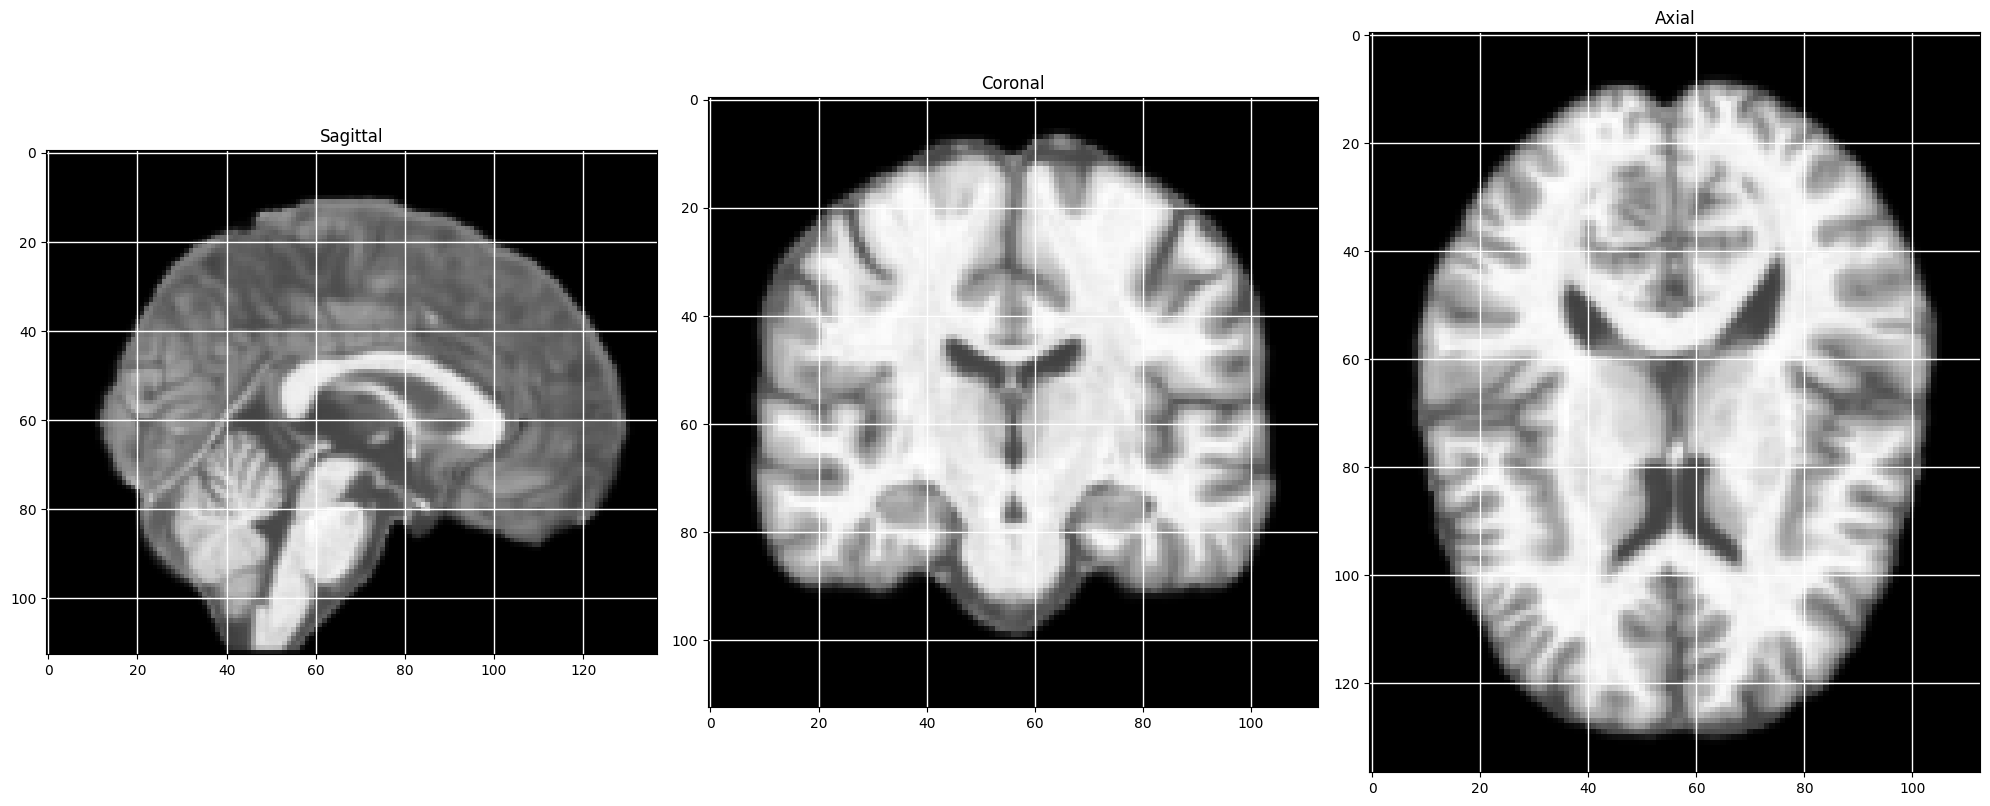

In [5]:
sample_t1_path = all_subjects[0]['t1']
image = nib.load(sample_t1_path).get_fdata()
f, axarr = plt.subplots(1, 3, figsize=(20, 10))
H, W, D  = image.shape

# 1. Sagittal View
axarr[0].imshow(np.flip(image[H // 2, :, :].T, axis=0), cmap='gray')
axarr[0].set_title('Sagittal')
axarr[0].grid(True, color='white', linestyle='-', linewidth=1) 
axarr[0].tick_params(colors='black') 

# 2. Coronal View
axarr[1].imshow(np.flip(image[:, W // 2, :].T, axis=0), cmap='gray')
axarr[1].set_title('Coronal')
axarr[1].grid(True, color='white', linestyle='-', linewidth=1)
axarr[1].tick_params(colors='black')

# 3. Axial View
axarr[2].imshow(image[:, :, D // 2].T, cmap='gray')
axarr[2].set_title('Axial')
axarr[2].grid(True, color='white', linestyle='-', linewidth=1)
axarr[2].tick_params(colors='black')

plt.tight_layout()
#plt.savefig('example_cam_can_grid.png', bbox_inches='tight')
plt.show()

# Data loading and visualization

In [6]:
def build_4class_label(t1: np.ndarray, p_gm: np.ndarray, p_wm: np.ndarray,
                        brain_intensity_thresh: float = 1e-3,
                        csf_floor: float = 0.05) -> np.ndarray:
    brain_mask = t1 > brain_intensity_thresh

    p_gm = np.clip(p_gm, 0, 1)
    p_wm = np.clip(p_wm, 0, 1)
    p_csf = np.clip(1.0 - p_gm - p_wm, 0, 1)
    p_csf = np.where(brain_mask, np.maximum(p_csf, csf_floor * (p_gm + p_wm < 0.1)), 0.0)

    p_bg = np.where(brain_mask, 0.0, 1.0)

    stack = np.stack([p_bg, p_csf, p_gm, p_wm], axis=0)  
    label = np.argmax(stack, axis=0).astype(np.int64)
    label[~brain_mask] = 0
    return label


def load_subjects(subject_list: List[Dict[str, str]]) -> Tuple[List[str], List[np.ndarray], List[np.ndarray]]:
    ids, images, labels = [], [], []
    for subj in tqdm(subject_list, desc='Loading subjects'):
        t1 = load_nii(subj['t1'])
        p_gm = load_nii(subj['gm'])
        p_wm = load_nii(subj['wm'])
        if not (t1.shape == p_gm.shape == p_wm.shape):
            print(f"[warn] shape mismatch for subject {subj['id']}: "
                  f"T1={t1.shape}, GM={p_gm.shape}, WM={p_wm.shape} - skipping")
            continue
        label = build_4class_label(t1, p_gm, p_wm)
        ids.append(subj['id'])
        images.append(t1)
        labels.append(label)
    return ids, images, labels

all_subjects = discover_subjects(DATA_ROOT)
filenames, all_images, all_segmentations = load_subjects(all_subjects)

np.random.seed(10282022)

all_keys = np.asarray(range(len(filenames)))
ratio_test = max(1, int(0.1 * len(all_keys)))  # 10% val; 10% test
val_keys = np.random.choice(all_keys, min(2 * ratio_test, len(all_keys)), replace=False)
test_keys = np.random.choice(val_keys, min(ratio_test, len(val_keys)), replace=False)

train_files, val_files, test_files = [], [], []
images_train, images_val, images_test = [], [], []
segmentations_train, segmentations_val, segmentations_test = [], [], []

for scan_id in tqdm(all_keys):
    subj_id = filenames[scan_id]
    img = all_images[scan_id]
    seg = all_segmentations[scan_id]
    if scan_id in test_keys:
        test_files.append(subj_id)
        images_test.append(img)
        segmentations_test.append(seg)
    elif scan_id in val_keys:
        val_files.append(subj_id)
        images_val.append(img)
        segmentations_val.append(seg)
    else:
        train_files.append(subj_id)
        images_train.append(img)
        segmentations_train.append(seg)

        
print(f'{len(images_train)} train files')
print(f'{len(images_val)} val files')
print(f'{len(images_test)} test files')

100%|██████████| 377/377 [00:00<00:00, 302111.69it/s]

303 train files
37 val files
37 test files


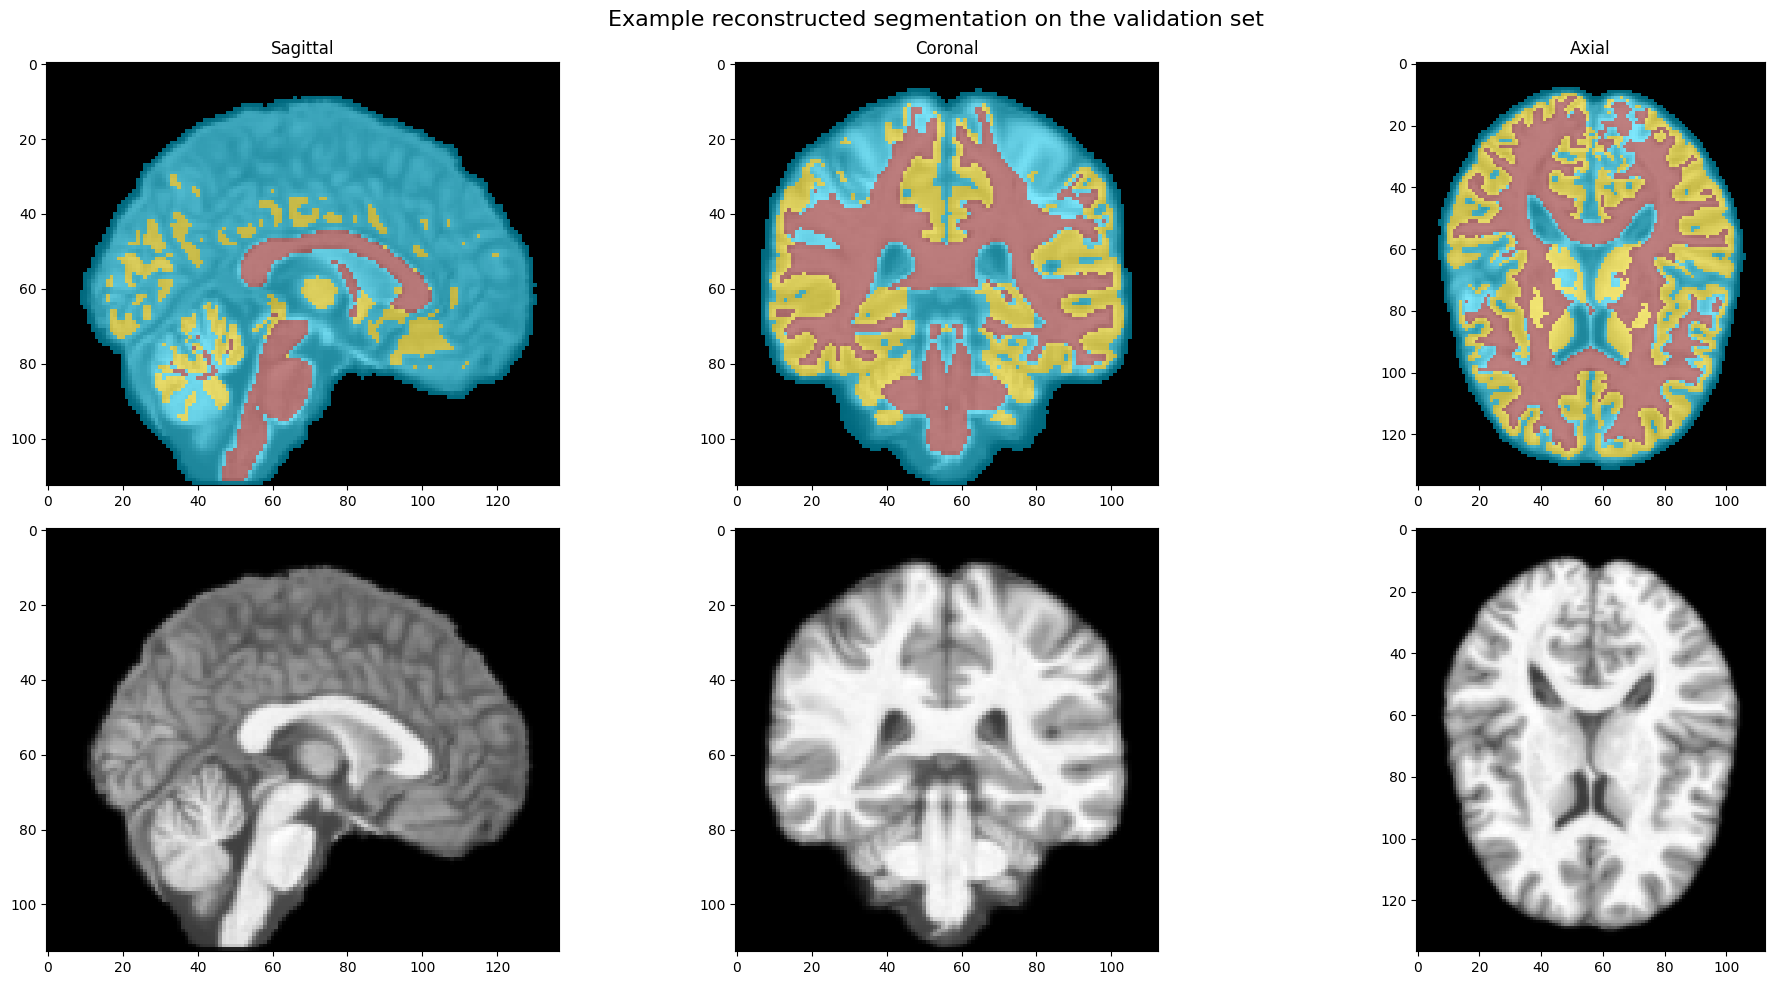

In [7]:
if len(images_val) > 0:
    im = images_val[0]
    plot_segmentations(im, segmentations_val[0], i=im.shape[-1] // 2,
                        title='Example reconstructed segmentation on the validation set')

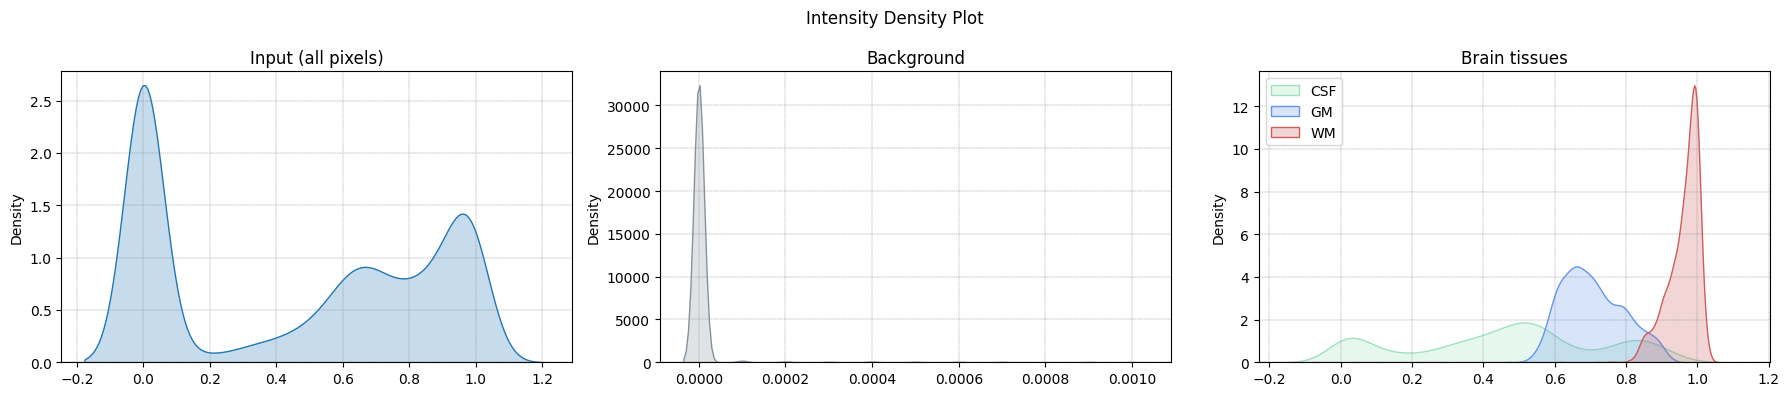

In [8]:
slice_id = 0
im_ = images_val[slice_id][:, :, 47].flatten()
seg_ = segmentations_val[slice_id][:, :, 47].flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Intensity Density Plot')

sns.kdeplot(im_, ax=axes[0], fill=True)
axes[0].set_title('Input (all pixels)')
axes[0].grid(True, color='gray', linestyle='--', linewidth=0.3)

sns.kdeplot(im_[seg_ == 0], ax=axes[1], fill=True, color='#85929E', label='Background')
axes[1].set_title('Background')
axes[1].grid(True, color='gray', linestyle='--', linewidth=0.3)

sns.kdeplot(im_[seg_ == 1], ax=axes[2], fill=True, color='#9FE2BF', label='CSF')
sns.kdeplot(im_[seg_ == 2], ax=axes[2], fill=True, color='#6495ED', label='GM')
sns.kdeplot(im_[seg_ == 3], ax=axes[2], fill=True, color='#CD5C5C', label='WM')
axes[2].set_title('Brain tissues')
axes[2].legend(loc='upper left')
axes[2].grid(True, color='gray', linestyle='--', linewidth=0.3)

plt.tight_layout()
plt.show()

# Unsupervised approach: K-Means

In [9]:
def Dice(pred, target, num_classes=4):
    """Returns mean Dice score and per-class Dice scores."""
    dice_scores = []
    for c in range(num_classes):
        pred_c = (pred == c)
        target_c = (target == c)
        intersection = np.logical_and(pred_c, target_c).sum()
        union = pred_c.sum() + target_c.sum()
        if union == 0:
            dice_scores.append(1.0)  
        else:
            dice_scores.append(2.0 * intersection / union)
    mean_dice = np.mean(dice_scores)
    return mean_dice, dice_scores

def maximize_dice_assignment(pred_seg, gt_seg, num_classes=4):
    """Remap cluster IDs to class IDs by maximising the Dice score matrix."""
    pred_labels = np.unique(pred_seg)
    cost = np.zeros((num_classes, num_classes))
    for i, pl in enumerate(pred_labels):
        for j in range(num_classes):
            intersection = np.logical_and(pred_seg == pl, gt_seg == j).sum()
            union = (pred_seg == pl).sum() + (gt_seg == j).sum()
            cost[i, j] = 2.0 * intersection / union if union > 0 else 0.0

    row_ind, col_ind = linear_sum_assignment(-cost)  # maximise
    mapping = {pred_labels[r]: col_ind[r] for r in row_ind}
    return np.vectorize(mapping.get)(pred_seg)

def get_best_and_worst_ids(predictions, ground_truth):
    best_id, worst_id = -1, -1
    best_performance, worst_performance = float('-inf'), float('inf')

    for i, (pred, gt) in enumerate(zip(predictions, ground_truth)):
        dice_score = Dice(pred, gt)[0]
        if dice_score > best_performance:
            best_performance = dice_score
            best_id = i
        if dice_score < worst_performance:
            worst_performance = dice_score
            worst_id = i

    return {
        'best_id': best_id,
        'best_performance': best_performance,
        'worst_id': worst_id,
        'worst_performance': worst_performance
    }

def visualize_best_and_worst_samples(predictions, ground_truth, images, i_best=47, i_worst=47):
    return_dict = get_best_and_worst_ids(predictions, ground_truth)

    best_id = return_dict['best_id']
    worst_id = return_dict['worst_id']

    plot_segmentations(images[best_id], predictions[best_id], i=i_best,
                       title=f'Best prediction on the test set (Dice: {return_dict["best_performance"]:.2f})')

    plot_segmentations(images[worst_id], predictions[worst_id], i=i_worst,
                       title=f'Worst prediction on the test set (Dice: {return_dict["worst_performance"]:.2f})')

In [10]:
# --- Unsupervised Method 1: K-Means ---
ims_test = images_test  
seg_test = np.array(segmentations_test)

def unsupervised_method(data, labels):
    num_clusters = 4
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(data.reshape(-1, 1))
    return cluster_assignments

desired_length = len(ims_test)
seg_list_1 = [0] * desired_length
pred_seg_1 = [0] * desired_length

for i in range(len(ims_test)):
    im   = ims_test[i].flatten()
    seg  = seg_test[i].flatten()
    pred = unsupervised_method(im, seg)
    pred = maximize_dice_assignment(pred, seg)
    pred_seg_1[i] = pred
    seg_list_1[i] = seg

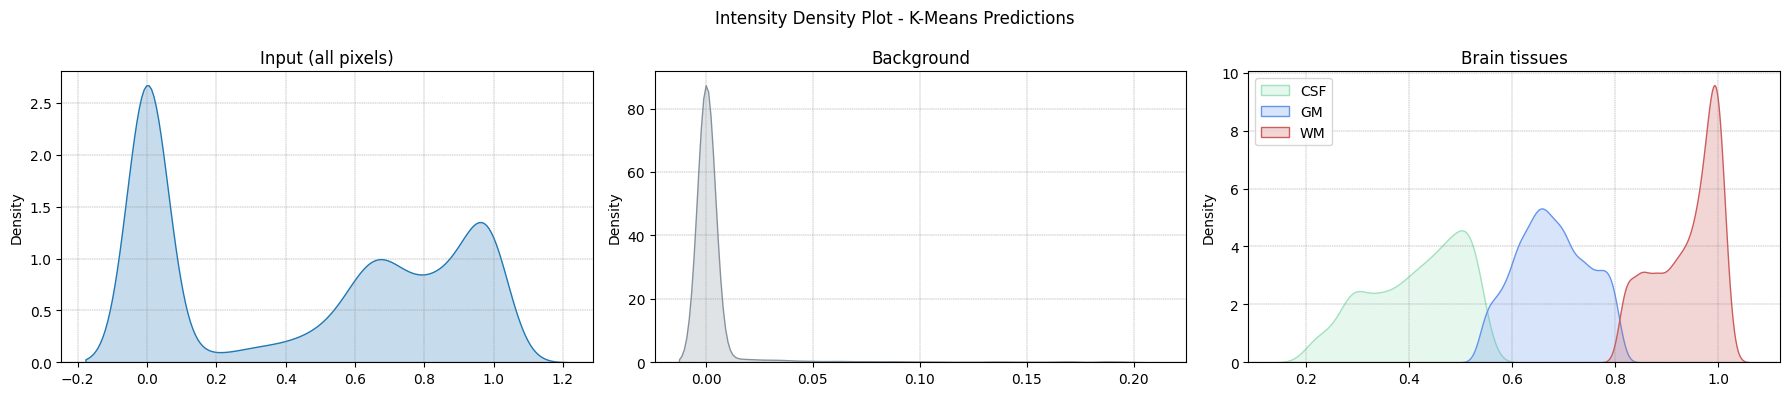

In [11]:
im_  = ims_test[0][:, :, 47].flatten()
seg_shape = ims_test[0].shape
seg_ = pred_seg_1[0].reshape(ims_test[0].shape)[:, :, 47].flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Intensity Density Plot - K-Means Predictions')

sns.kdeplot(im_, ax=axes[0], fill=True)
axes[0].set_title('Input (all pixels)')
axes[0].grid(True, color='gray', linestyle='--', linewidth=0.3)

noise = np.random.normal(0, 1e-5, size=im_[seg_ == 0].shape)
sns.kdeplot(im_[seg_ == 0] + noise, ax=axes[1], fill=True, color='#85929E', label='Background')
axes[1].set_title('Background')
axes[1].grid(True, color='gray', linestyle='--', linewidth=0.3)

sns.kdeplot(im_[seg_ == 1], ax=axes[2], fill=True, color='#9FE2BF', label='CSF')
sns.kdeplot(im_[seg_ == 2], ax=axes[2], fill=True, color='#6495ED', label='GM')
sns.kdeplot(im_[seg_ == 3], ax=axes[2], fill=True, color='#CD5C5C', label='WM')
axes[2].set_title('Brain tissues')
axes[2].legend(loc='upper left')
axes[2].grid(True, color='gray', linestyle='--', linewidth=0.3)

plt.tight_layout()
plt.show()

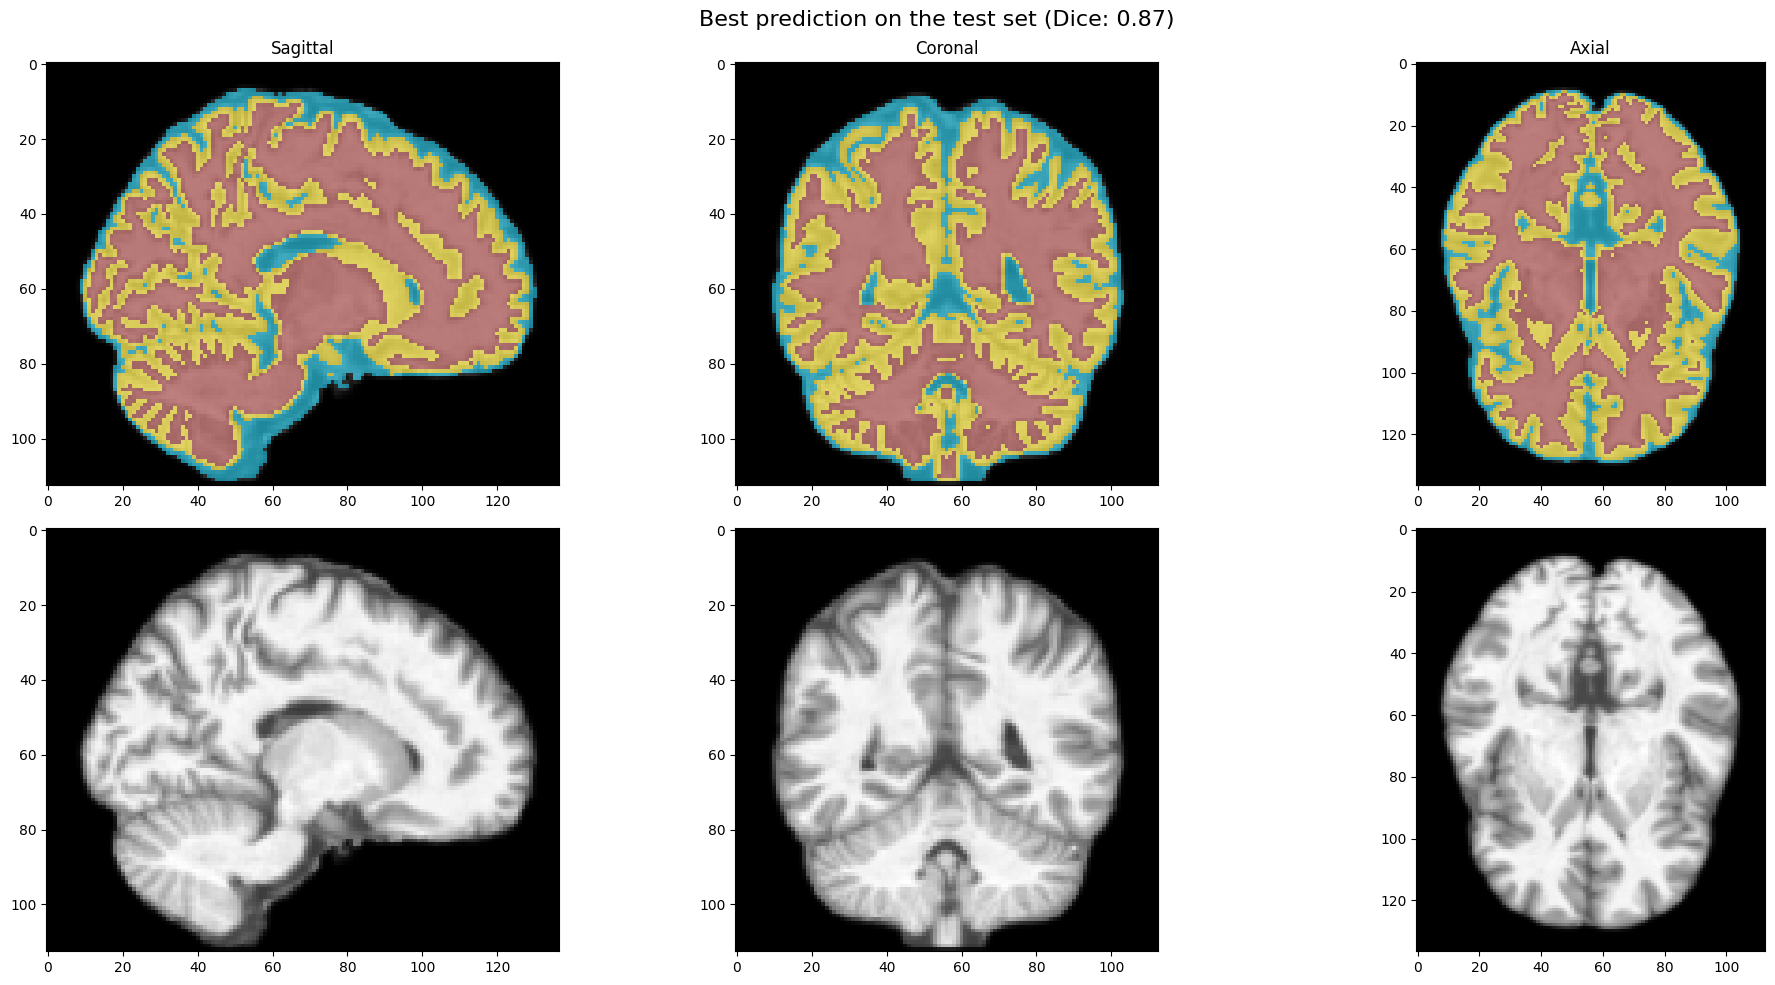

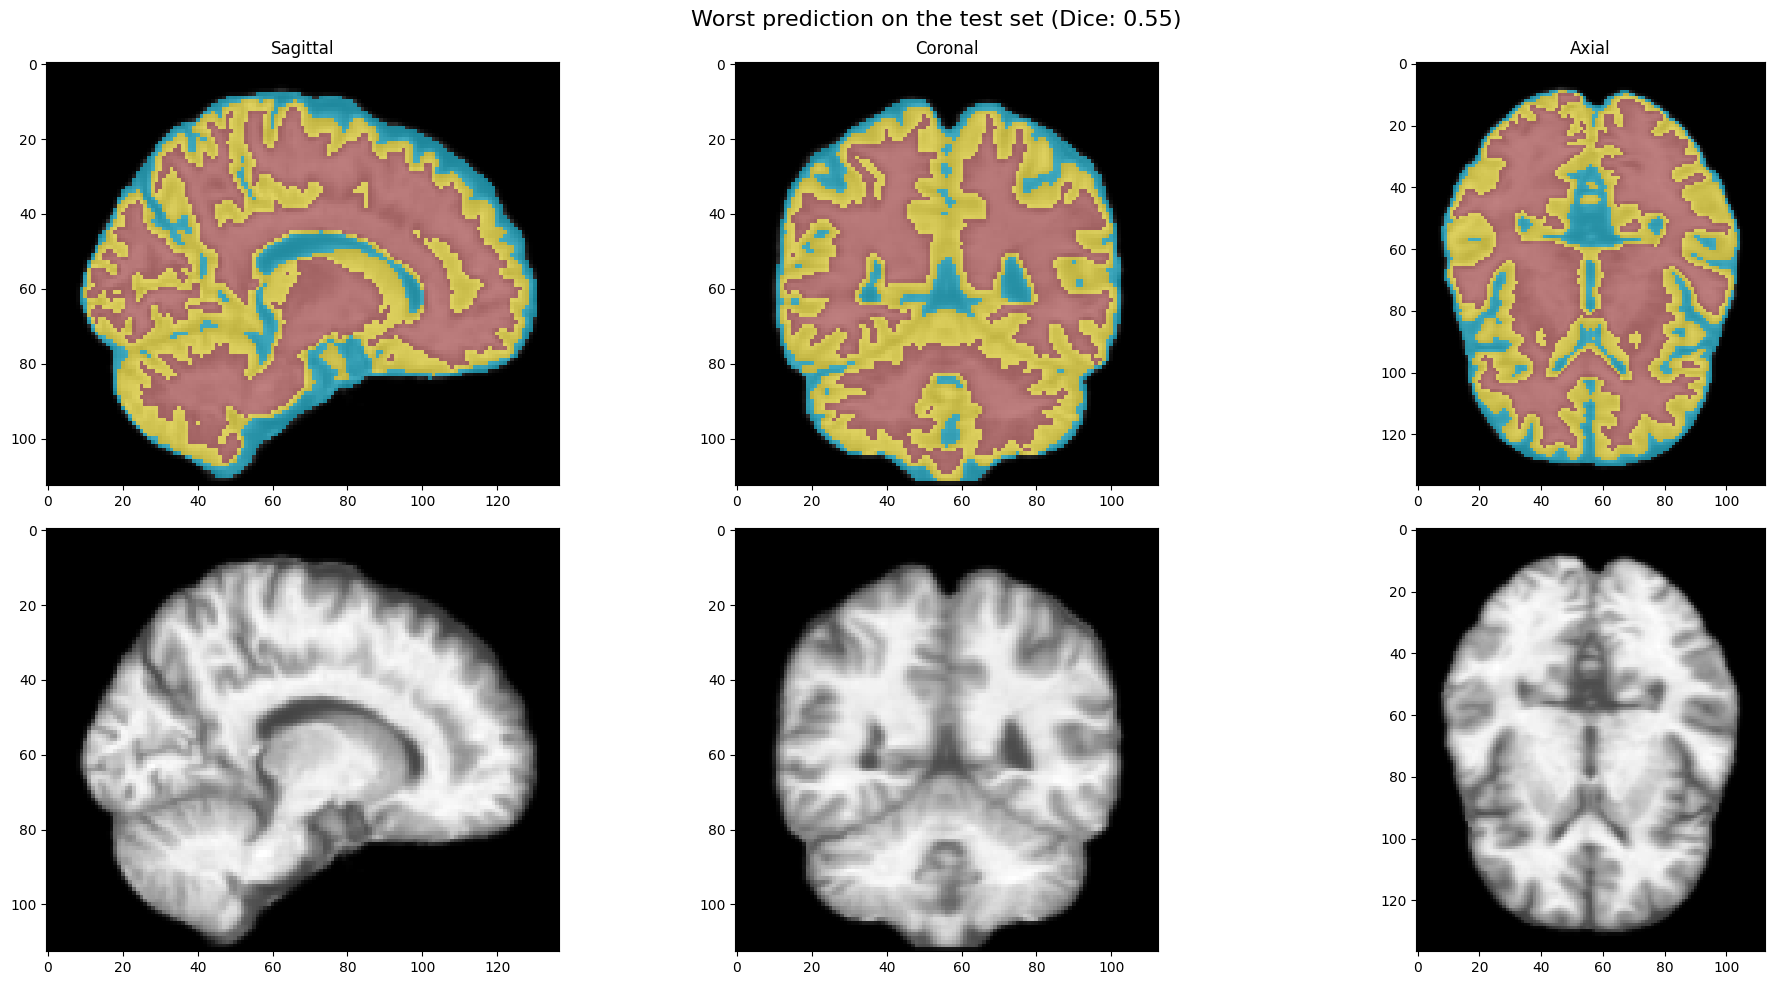

In [12]:
original_shape = ims_test[0].shape
pred_seg_1 = [item.reshape(original_shape) for item in pred_seg_1]
seg_list_1 = [item.reshape(original_shape) for item in seg_list_1]

visualize_best_and_worst_samples(pred_seg_1, seg_list_1, ims_test)

# Deep Supervised approach

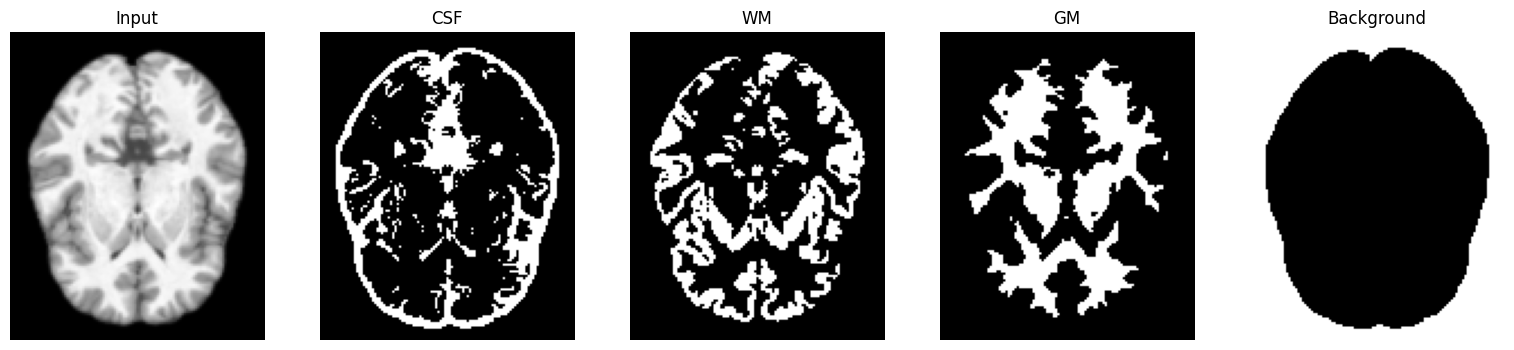

In [13]:
im = images_val[0] 

csf, wm, gm, background = np.zeros(im.shape), np.zeros(im.shape), np.zeros(im.shape), np.zeros(im.shape)

csf[segmentations_val[0] == 1] = 1
wm[segmentations_val[0] == 2] = 1
gm[segmentations_val[0] == 3] = 1
background[segmentations_val[0] == 0] = 1

elements = [im, csf, wm, gm, background]
titles = ['Input', 'CSF', 'WM', 'GM', 'Background']

diffp, axarr = plt.subplots(1, len(elements), gridspec_kw={'wspace': 0, 'hspace': 0})
diffp.set_size_inches(len(elements) * 4, 4)

for idx_arr in range(len(axarr)):
    axarr[idx_arr].axis('off')
    el = np.squeeze(elements[idx_arr][:,:,47])
    axarr[idx_arr].imshow(el.T, cmap='gray')
    axarr[idx_arr].set_title(titles[idx_arr])
    
plt.show()

In [14]:
class Conv3d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)

    def forward(self, x):
        return self.conv(x)
    
class SEBlock(nn.Module):  
    def __init__(self, channel, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c = x.shape[:2]
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)

In [15]:
class UNet3D(nn.Module):  
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down1 = nn.Sequential(
            Conv3d(in_channels, 16, 3, 1),
            nn.BatchNorm3d(16), nn.ReLU(inplace=True), SEBlock(16)
        )
        self.down2 = nn.Sequential(
            Conv3d(16, 32, 3, 1),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True), SEBlock(32)
        )
        self.down3 = nn.Sequential(
            Conv3d(32, 64, 3, 1),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True), SEBlock(64)
        )
        self.bottleneck = nn.Sequential(
            Conv3d(64, 96, 3, 1), nn.BatchNorm3d(96), nn.ReLU(inplace=True),
            Conv3d(96, 64, 3, 1), nn.BatchNorm3d(64), nn.ReLU(inplace=True)
        )
        self.up1 = nn.Sequential(
            Conv3d(128, 64, 3, 1), nn.BatchNorm3d(64), nn.ReLU(inplace=True)
        )
        self.up2 = nn.Sequential(
            Conv3d(64, 32, 3, 1), nn.BatchNorm3d(32), nn.ReLU(inplace=True)
        )
        self.up3 = nn.Sequential(
            Conv3d(32, out_channels, 3, 1),
            nn.BatchNorm3d(out_channels), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        bn = self.bottleneck(d3)
        u1 = self.up1(torch.cat([d3, bn], dim=1))  
        u2 = self.up2(u1)
        return self.up3(u2)

In [16]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    use_amp = True
    amp_device = 'cuda'
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    use_amp = False   
    amp_device = 'cpu'
else:
    device = torch.device('cpu')
    use_amp = False
    amp_device = 'cpu'

print(f"Using device: {device}")

Using device: mps


In [17]:
num_epochs = 30
batch_size = 1          
learningrate = 0.002

model = UNet3D(in_channels=1, out_channels=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learningrate)
scaler = GradScaler(device=amp_device)  

In [18]:
ims_train = torch.tensor(np.array(images_train)).unsqueeze(1).float()
ims_val   = torch.tensor(np.array(images_val)).unsqueeze(1).float()
seg_train = torch.tensor(np.array(segmentations_train)).long()
seg_val   = torch.tensor(np.array(segmentations_val)).long()

ims_test  = torch.tensor(np.array(images_test)).unsqueeze(1).float()
seg_test  = torch.tensor(np.array(segmentations_test)).long()
onehot_seg_test = torch.nn.functional.one_hot(seg_test, num_classes=4).permute(0, 4, 1, 2, 3)

In [19]:
class ImageSegDataset(Dataset):
    def __init__(self, images, segs, patch_size=(64, 64, 64)):
        self.images = images
        self.segs = segs
        self.patch_size = patch_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        seg = self.segs[idx]
        
        d, h, w = img.shape[1:]
        pd, ph, pw = self.patch_size
        
        z = np.random.randint(0, d - pd + 1)
        y = np.random.randint(0, h - ph + 1)
        x = np.random.randint(0, w - pw + 1)
        
        img_patch = img[:, z:z+pd, y:y+ph, x:x+pw]
        seg_patch = seg[z:z+pd, y:y+ph, x:x+pw]
        
        return {'image': img_patch, 'seg': seg_patch}
    
dataset_train = ImageSegDataset(ims_train, seg_train)
dataset_val   = ImageSegDataset(ims_val,   seg_val)
dataset_test  = ImageSegDataset(ims_test,  onehot_seg_test)

dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_val   = DataLoader(dataset_val,   batch_size=batch_size, shuffle=False)
dataloader_test  = DataLoader(dataset_test,  batch_size=batch_size, shuffle=False)

In [20]:
def evaluate(dataloader, model):
    model.eval()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            labels = batch['seg'].to(device)
            total_loss += criterion(model(images), labels).item()
            n += 1
    return total_loss / n

In [21]:
def train(dataloader_train, dataloader_val, model):
    loss_values, val_loss_values = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss, n = 0.0, 0

        if device.type == 'mps':
            torch.mps.empty_cache()

        t_data, t_to_device, t_fwd, t_bwd = 0.0, 0.0, 0.0, 0.0
        t_prev = time.perf_counter()

        with tqdm(dataloader_train, desc=f'Epoch {epoch}/{num_epochs}', unit='batch') as tepoch:
            for batch in tepoch:
                t0 = time.perf_counter()
                t_data += t0 - t_prev          

                images = batch['image'].to(device)
                labels = batch['seg'].to(device)
                if device.type == 'mps':
                    torch.mps.synchronize()
                t1 = time.perf_counter()
                t_to_device += t1 - t0          

                optimizer.zero_grad()

                if use_amp:
                    with autocast(device_type=amp_device):
                        outputs = model(images)
                        train_loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    train_loss = criterion(outputs, labels)
                if device.type == 'mps':
                    torch.mps.synchronize()
                t2 = time.perf_counter()
                t_fwd += t2 - t1                

                if use_amp:
                    scaler.scale(train_loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    train_loss.backward()
                    optimizer.step()
                if device.type == 'mps':
                    torch.mps.synchronize()
                t3 = time.perf_counter()
                t_bwd += t3 - t2                 

                epoch_loss += train_loss.item()
                n += 1
                tepoch.set_postfix(loss=epoch_loss / n)
                t_prev = time.perf_counter()

                if n == 10:   
                    print(f"\n[Profiling primi 10 batch]")
                    print(f"  Data loading:   {t_data:.2f}s  ({t_data/n:.3f}s/batch)")
                    print(f"  To device:      {t_to_device:.2f}s  ({t_to_device/n:.3f}s/batch)")
                    print(f"  Forward pass:   {t_fwd:.2f}s  ({t_fwd/n:.3f}s/batch)")
                    print(f"  Backward+step:  {t_bwd:.2f}s  ({t_bwd/n:.3f}s/batch)")
                    print()

        avg_train = epoch_loss / n
        avg_val   = evaluate(dataloader_val, model)
        loss_values.append(avg_train)
        val_loss_values.append(avg_val)
        print(f'Epoch [{epoch}/{num_epochs}]  train={avg_train:.4f}  val={avg_val:.4f}')

    return loss_values, val_loss_values, model

In [22]:
"""
loss_values, val_loss_values, trained_model = train(dataloader_train, dataloader_val, model)

plt.plot(loss_values,     label='Training Loss')
plt.plot(val_loss_values, label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend(); plt.show()

torch.save(model.state_dict(), 'trained_model.pth')
"""
model.load_state_dict(torch.load('trained_model.pth', map_location=device))

<All keys matched successfully>

In [23]:
def _gaussian_weight_map(patch_size, sigma_scale=0.125, device='cpu'):
    pd, ph, pw = patch_size
    coords = [torch.arange(s, dtype=torch.float32) for s in (pd, ph, pw)]
    zz, yy, xx = torch.meshgrid(*coords, indexing='ij')
 
    center = torch.tensor([(pd - 1) / 2, (ph - 1) / 2, (pw - 1) / 2])
    sigma = torch.tensor([pd, ph, pw]) * sigma_scale
 
    dist_sq = ((zz - center[0]) / sigma[0]) ** 2 + \
              ((yy - center[1]) / sigma[1]) ** 2 + \
              ((xx - center[2]) / sigma[2]) ** 2
 
    weight = torch.exp(-0.5 * dist_sq)
    weight = weight / weight.max()          
    weight = torch.clamp(weight, min=1e-4)  
 
    return weight.to(device)

In [24]:
def predict_volume(model, volume, patch_size=(64, 64, 64), overlap=0.5,
                    num_classes=4, device=None, batch_size=4, use_gaussian=True):
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    if isinstance(volume, np.ndarray):
        volume = torch.from_numpy(volume).float()
    elif not torch.is_tensor(volume):
        volume = torch.as_tensor(volume, dtype=torch.float32)

    if volume.dim() == 3:
        volume = volume.unsqueeze(0)  
    elif volume.dim() != 4:
        raise ValueError(
            f"Expected volume with 3 dims [D,H,W] or 4 dims [C,D,H,W], "
            f"got shape {tuple(volume.shape)}"
        )

    c_in, D, H, W = volume.shape
    pd, ph, pw = patch_size

    pad_d = max(0, pd - D)
    pad_h = max(0, ph - H)
    pad_w = max(0, pw - W)
    if pad_d or pad_h or pad_w:
        volume = F.pad(volume, (0, pad_w, 0, pad_h, 0, pad_d), mode='constant', value=0)
        D, H, W = volume.shape[1:]

    stride_d = max(1, int(pd * (1 - overlap)))
    stride_h = max(1, int(ph * (1 - overlap)))
    stride_w = max(1, int(pw * (1 - overlap)))

    def _starts(size, patch, stride):
        starts = list(range(0, max(size - patch, 0) + 1, stride))
        last = size - patch
        if starts[-1] != last:
            starts.append(last)
        return starts

    z_starts = _starts(D, pd, stride_d)
    y_starts = _starts(H, ph, stride_h)
    x_starts = _starts(W, pw, stride_w)

    output_sum = torch.zeros((num_classes, D, H, W), dtype=torch.float32, device=device)
    weight_sum = torch.zeros((D, H, W), dtype=torch.float32, device=device)

    if use_gaussian:
        patch_weight = _gaussian_weight_map(patch_size, device=device)
    else:
        patch_weight = torch.ones(patch_size, device=device)

    coords = [(z, y, x) for z in z_starts for y in y_starts for x in x_starts]

    volume = volume.to(device)

    with torch.no_grad():
        for i in range(0, len(coords), batch_size):
            batch_coords = coords[i:i + batch_size]
            patches = torch.stack([
                volume[:, z:z+pd, y:y+ph, x:x+pw] for (z, y, x) in batch_coords
            ], dim=0)  

            preds = model(patches)  

            for j, (z, y, x) in enumerate(batch_coords):
                output_sum[:, z:z+pd, y:y+ph, x:x+pw] += preds[j] * patch_weight.unsqueeze(0)
                weight_sum[z:z+pd, y:y+ph, x:x+pw] += patch_weight

    weight_sum = weight_sum.clamp(min=1e-8)
    output = output_sum / weight_sum.unsqueeze(0)

    if pad_d or pad_h or pad_w:
        orig_D, orig_H, orig_W = D - pad_d, H - pad_h, W - pad_w
        output = output[:, :orig_D, :orig_H, :orig_W]

    return output 

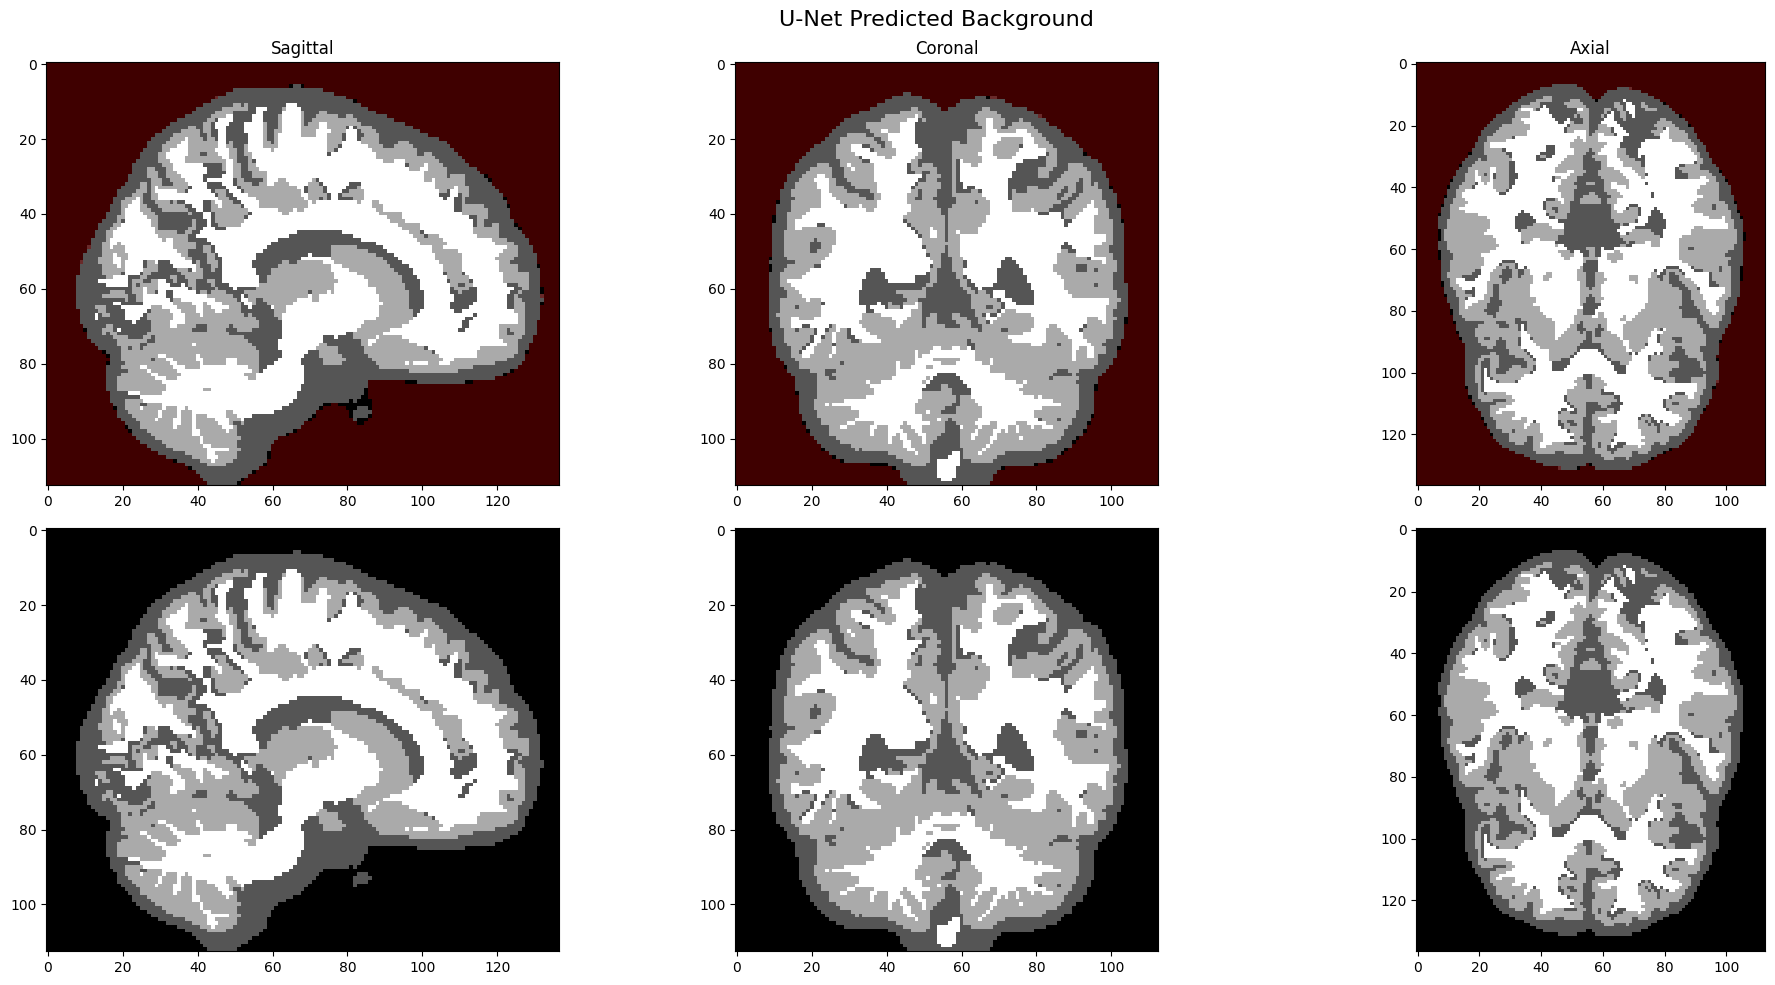

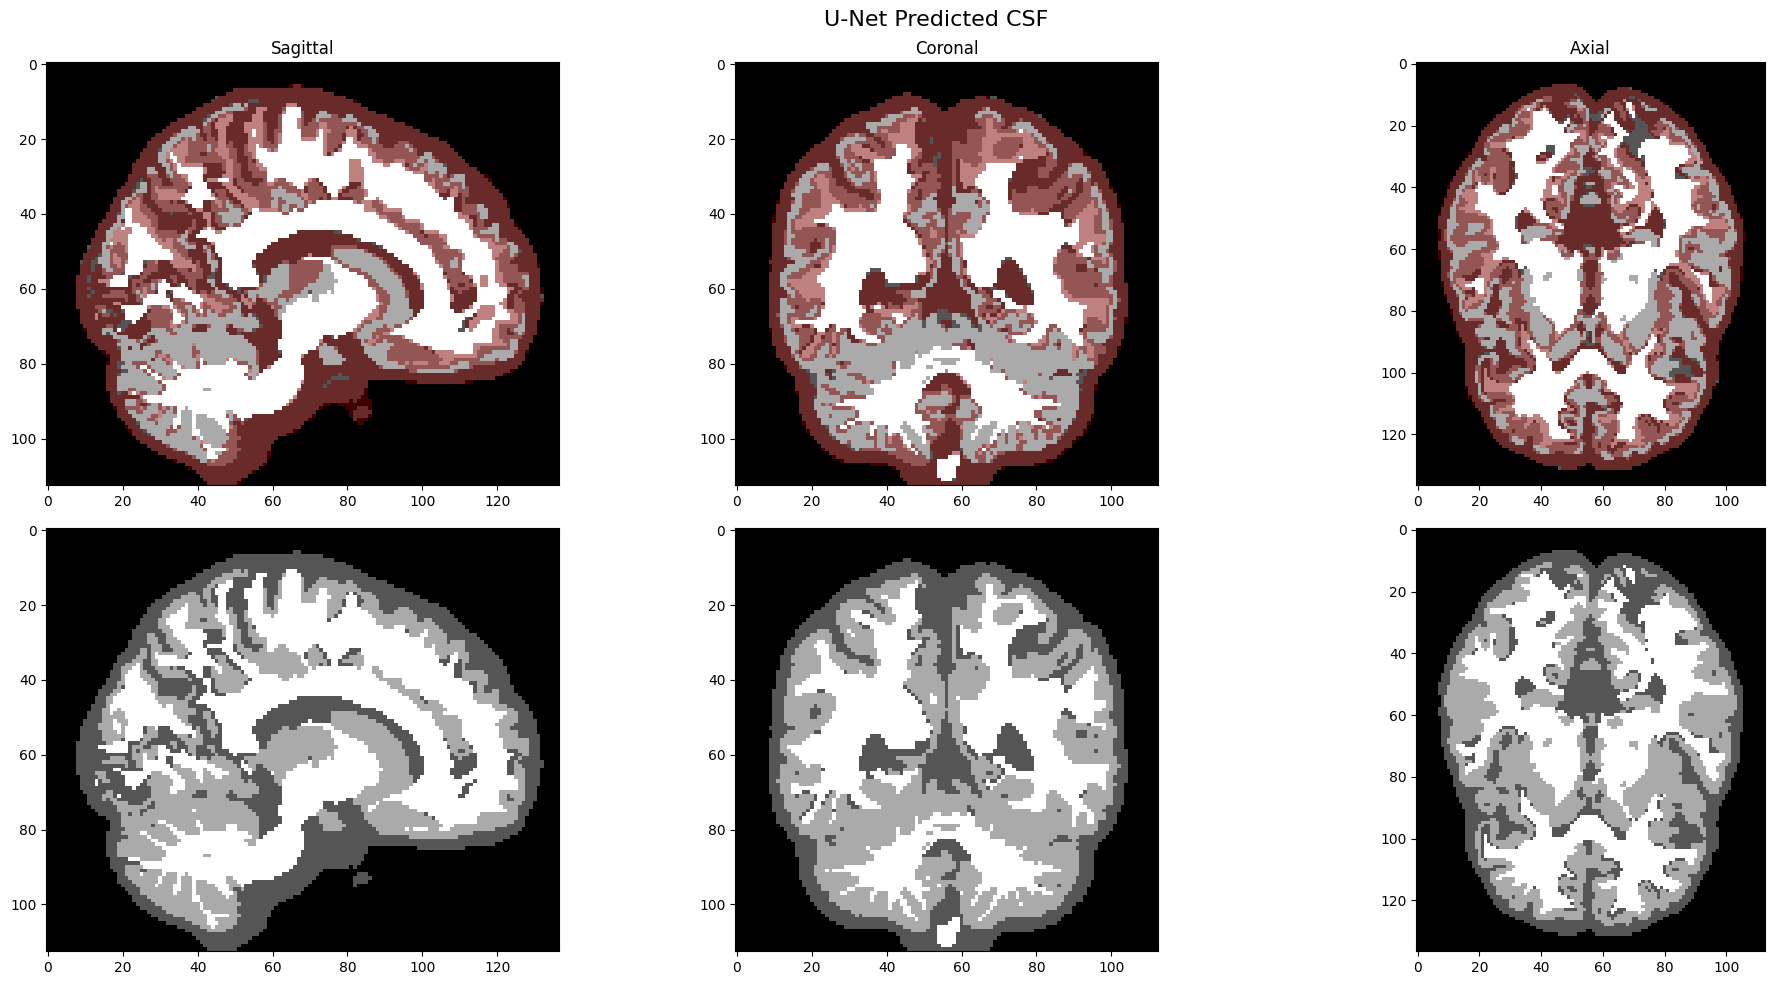

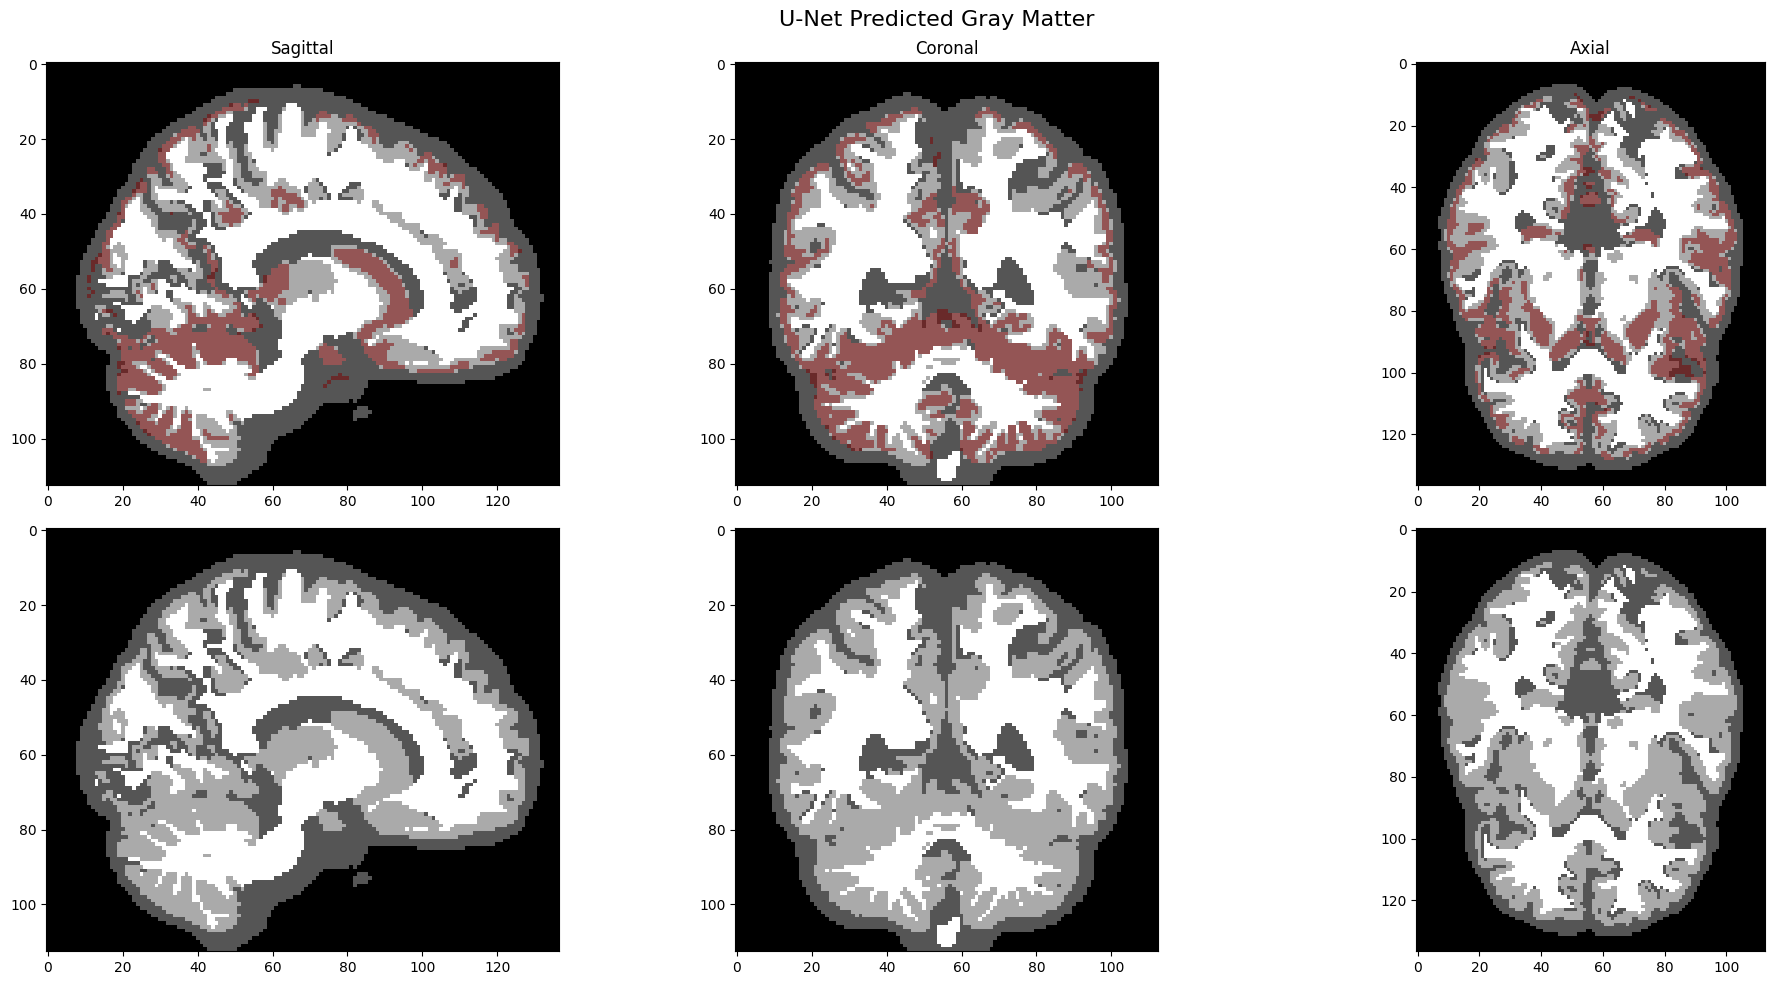

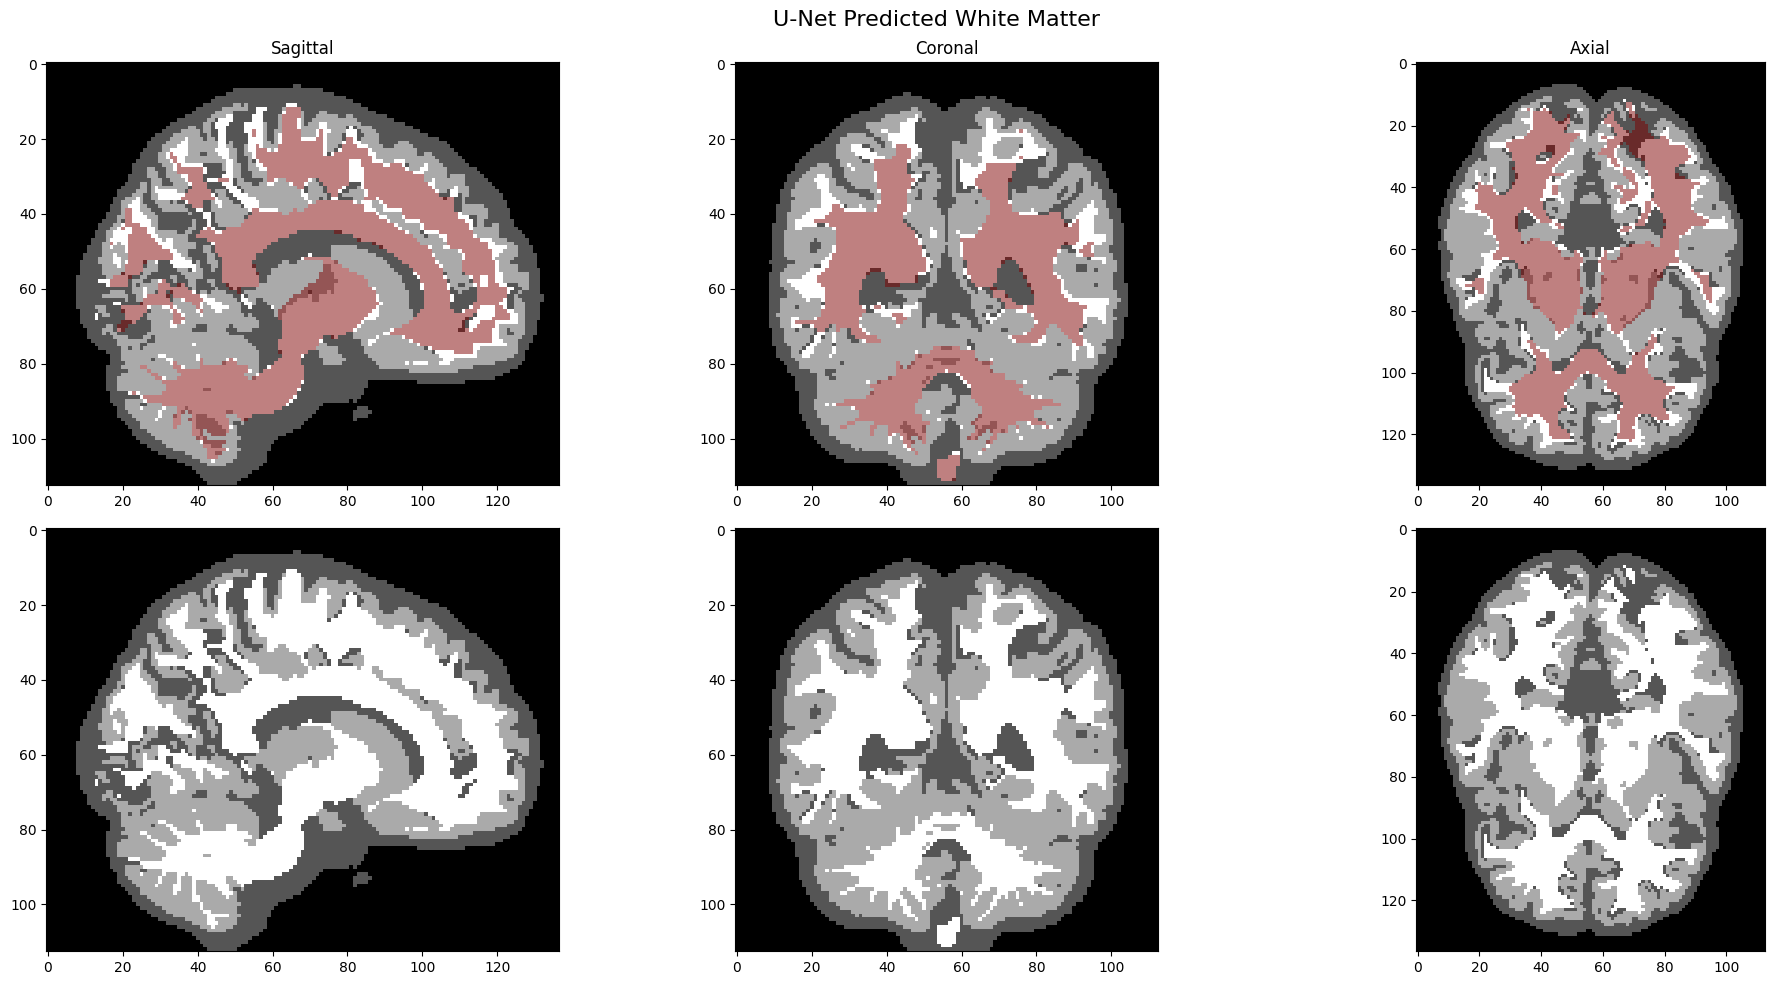

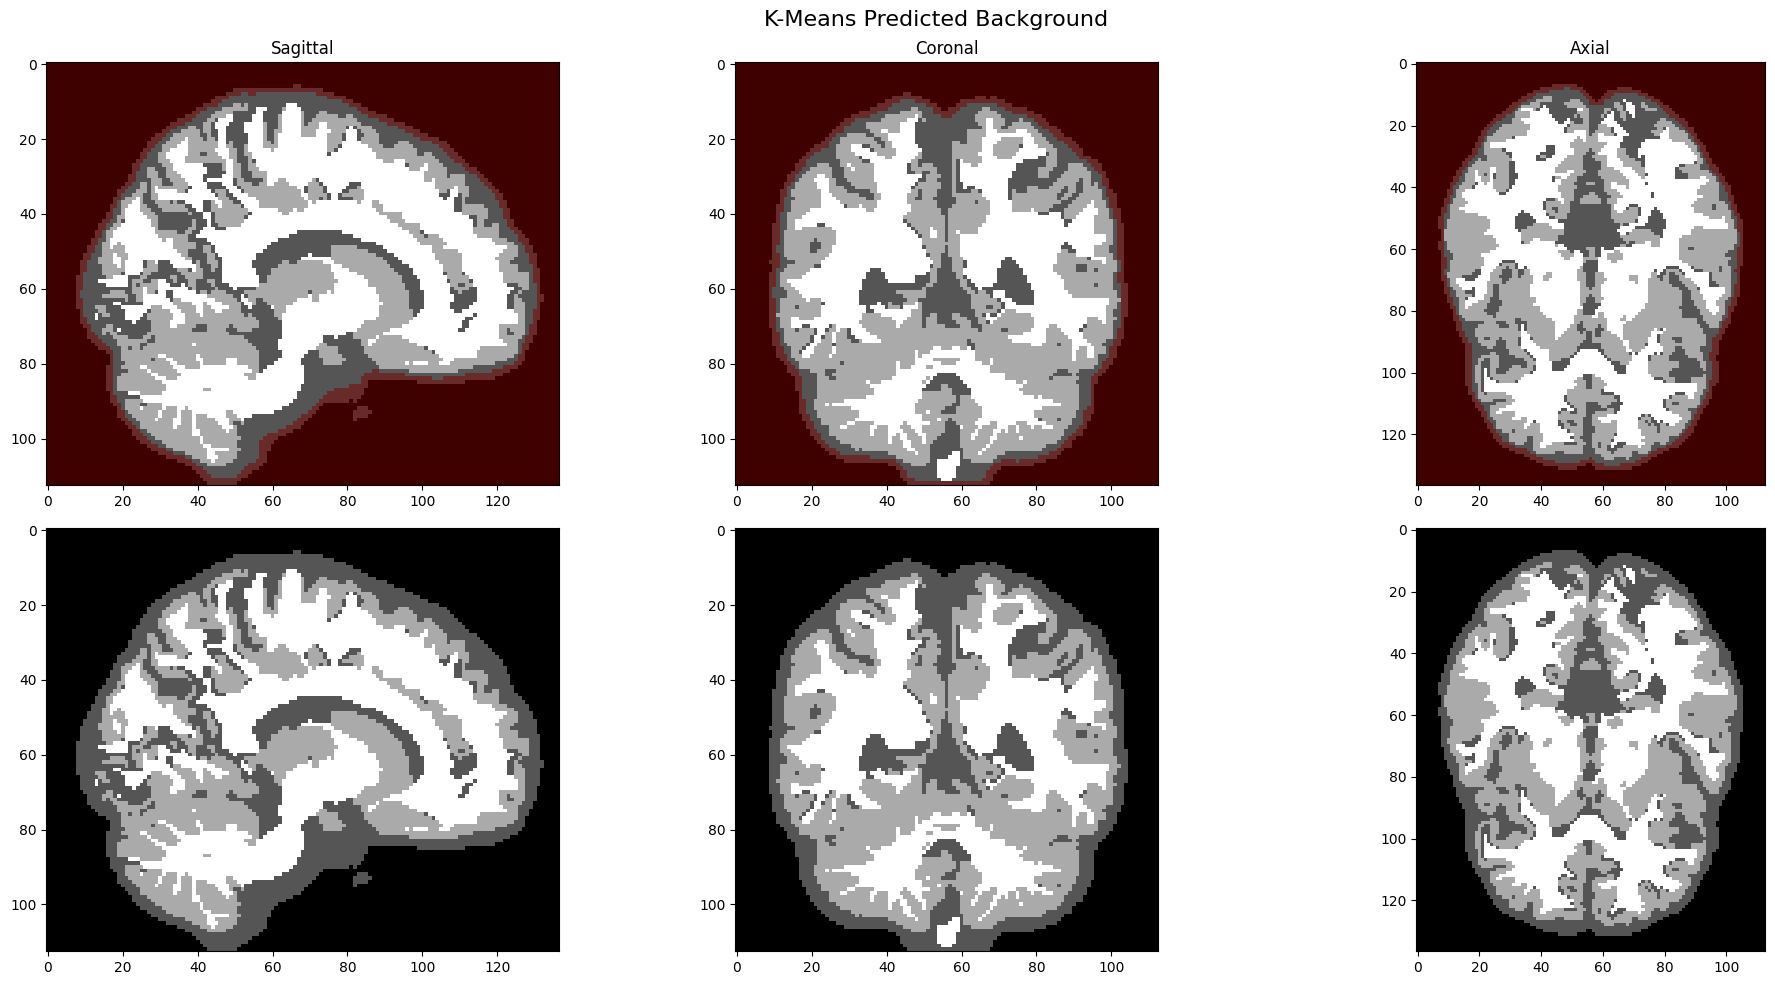

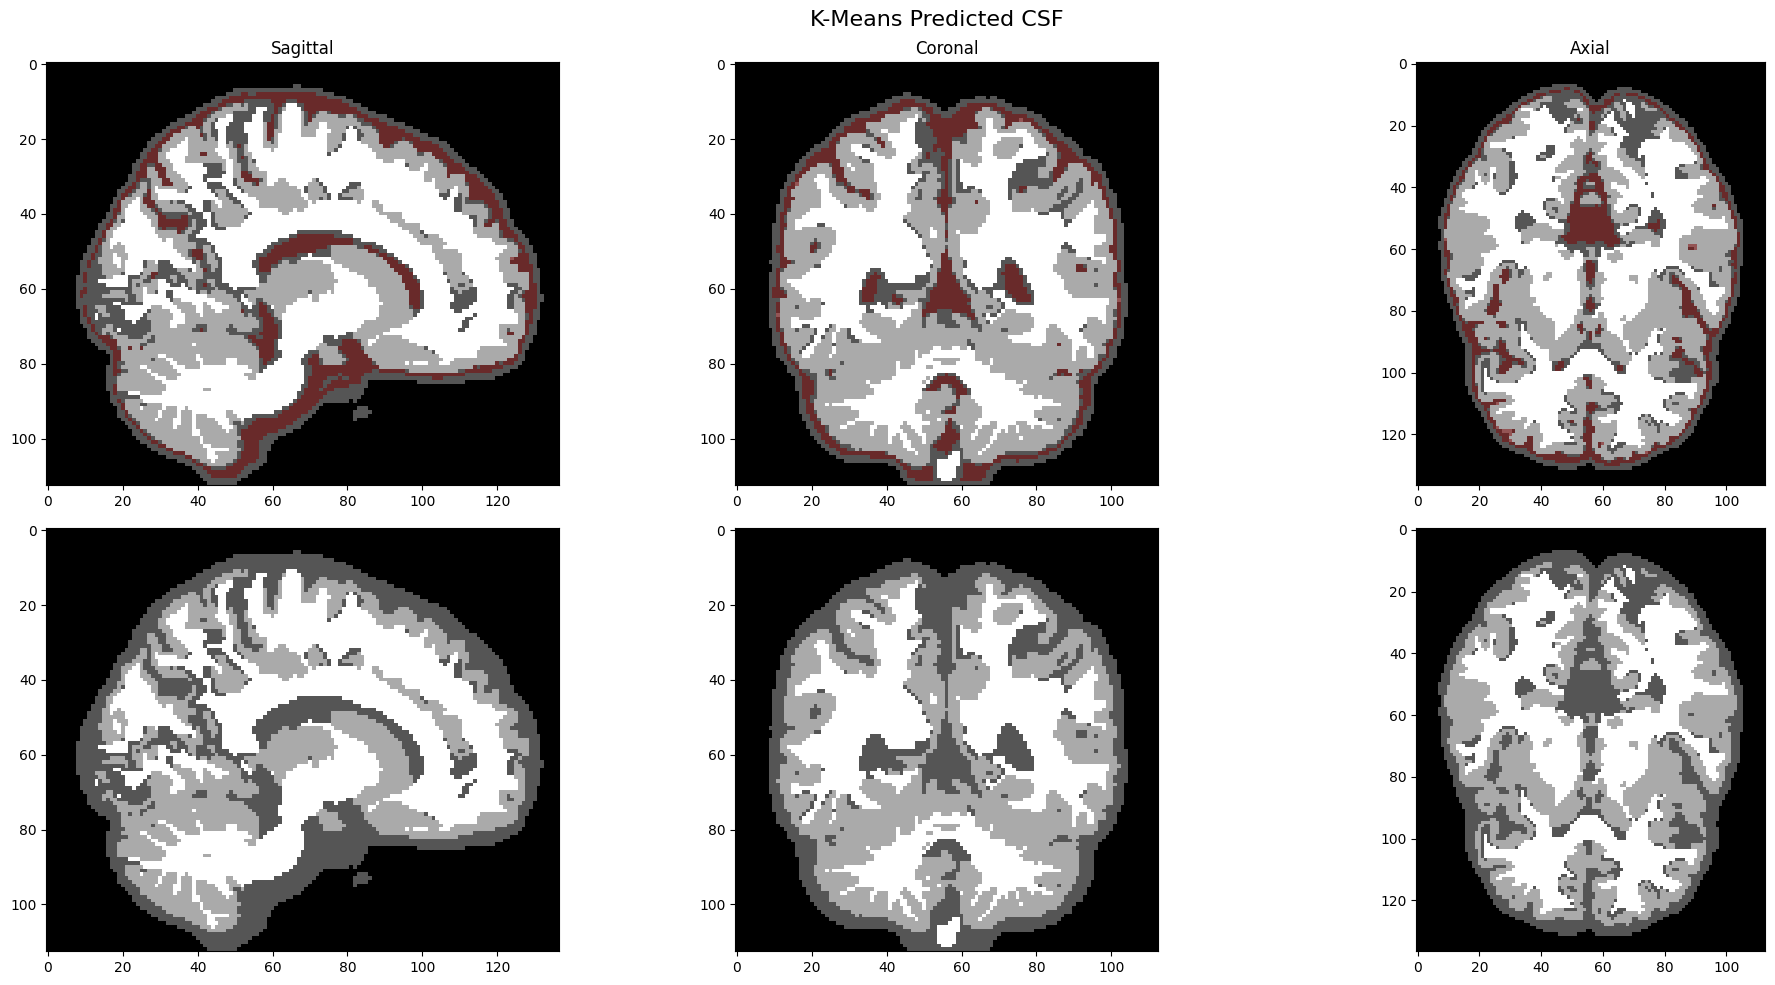

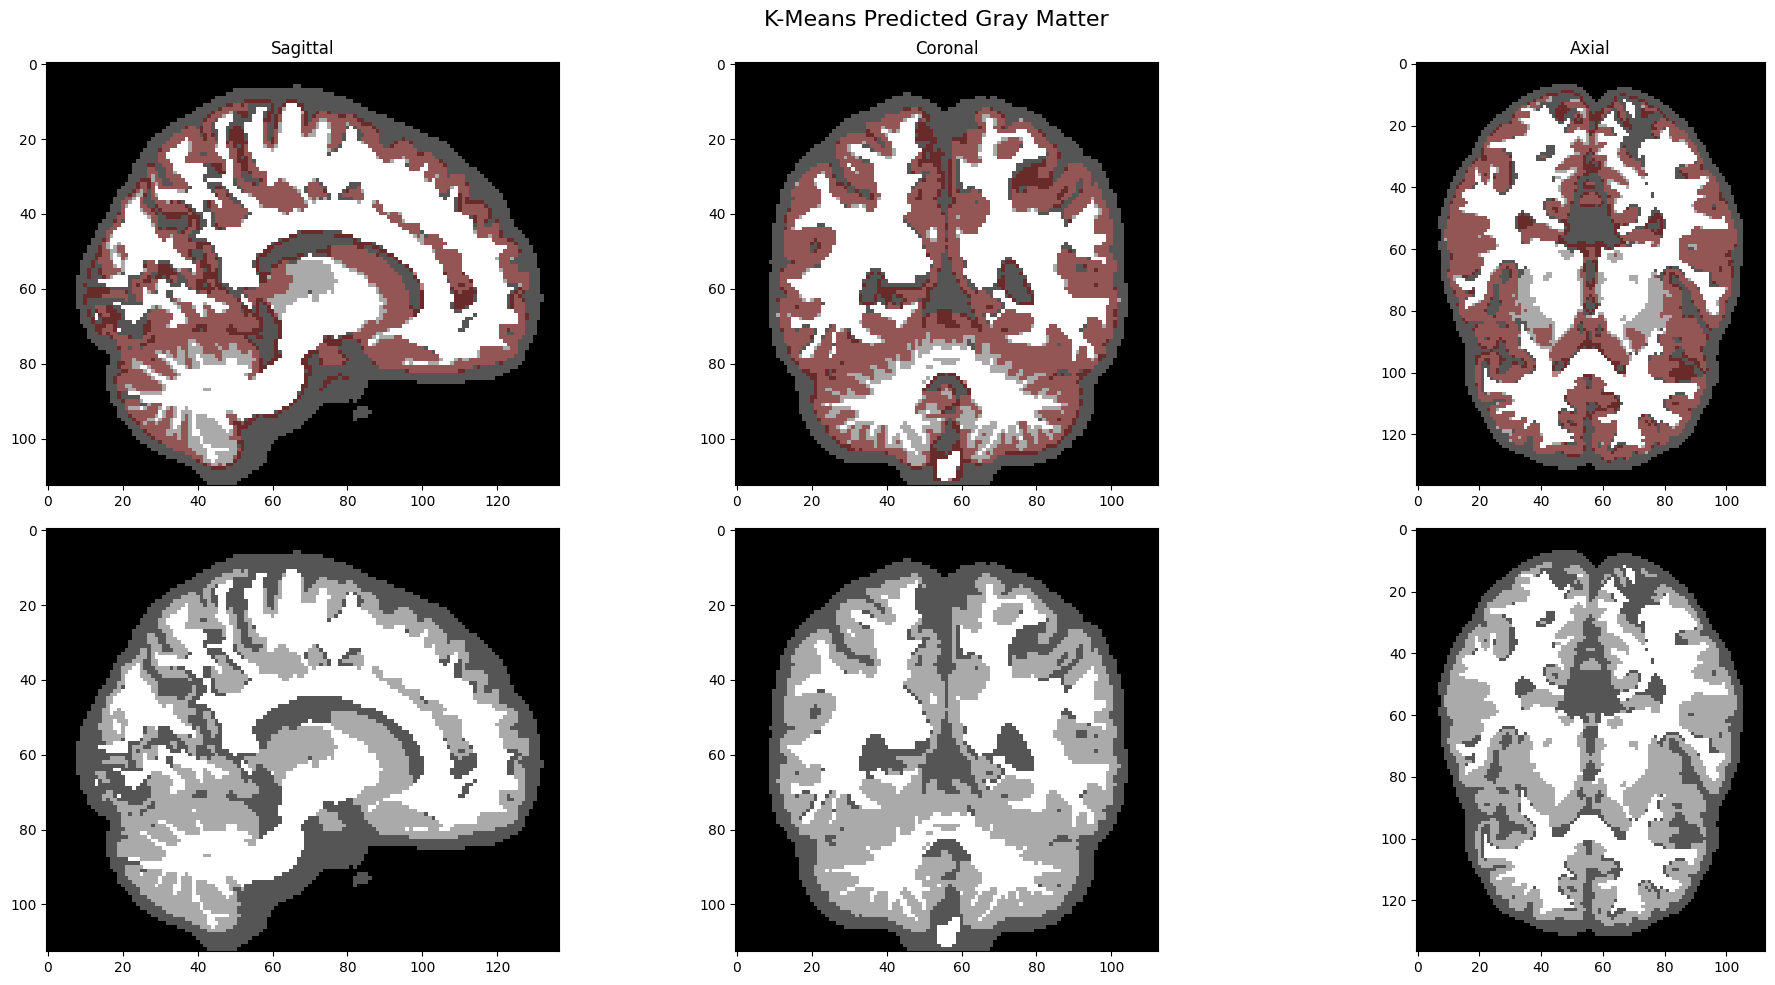

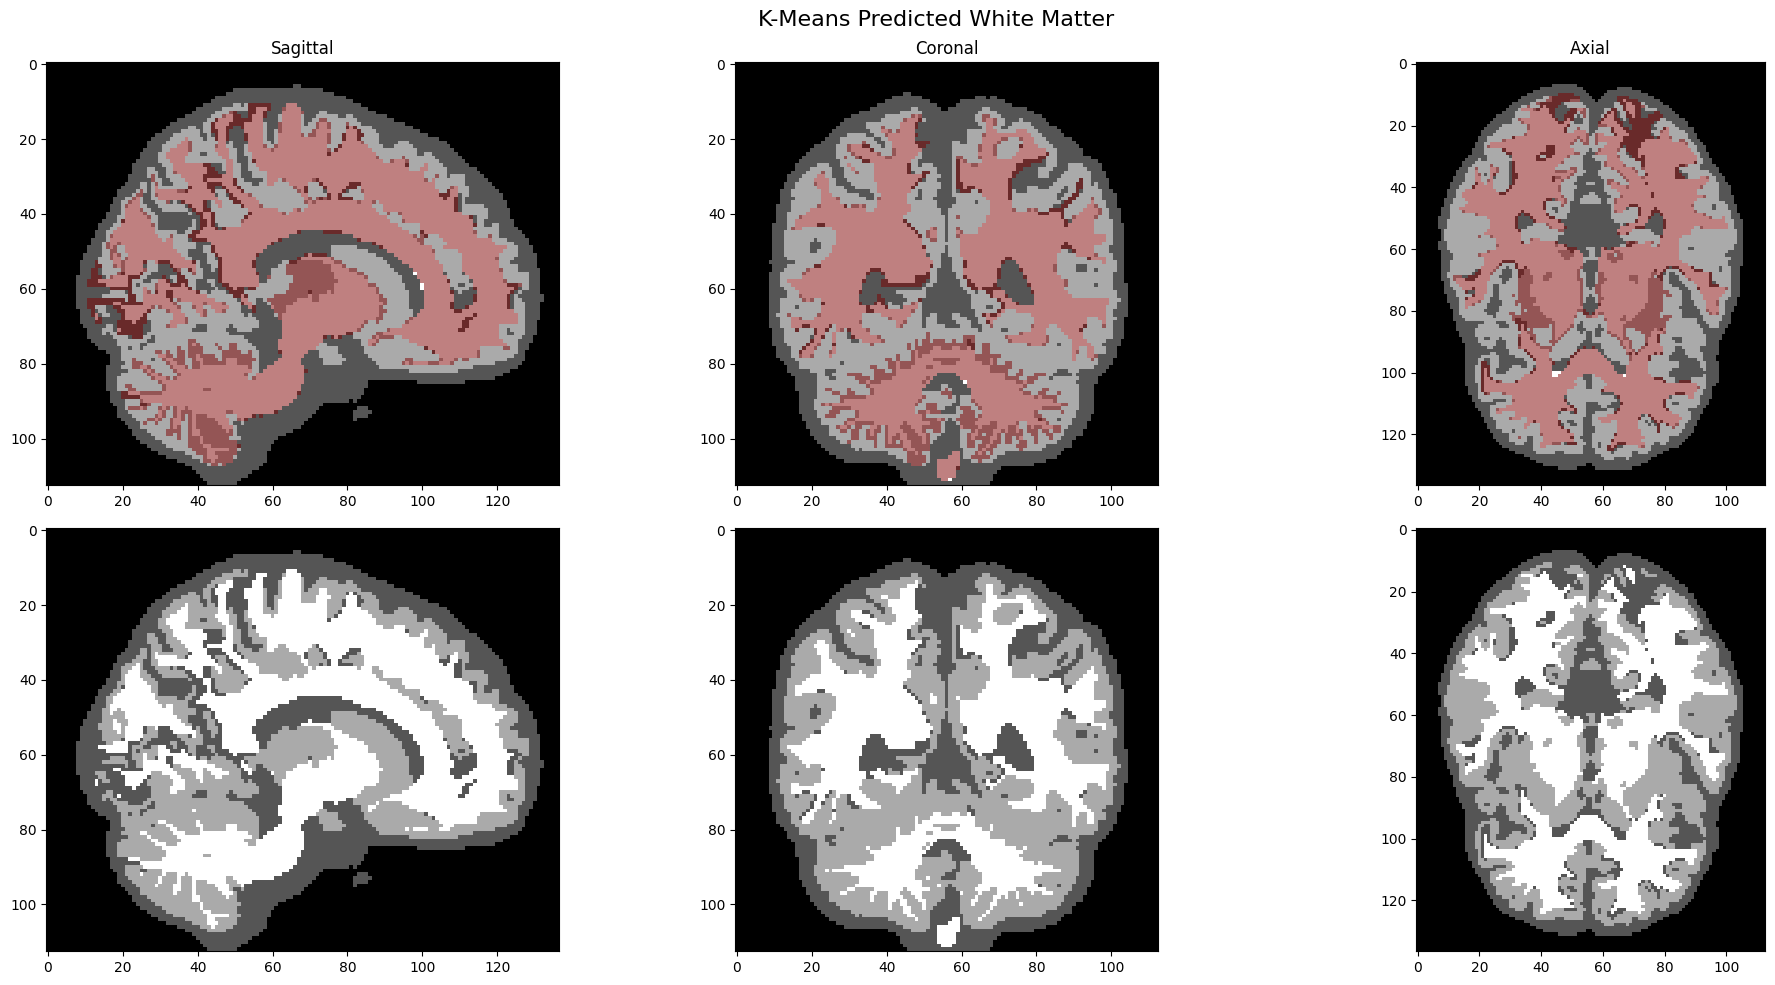

In [26]:
def predict_and_segment(model, volume, patch_size=(64, 64, 64), overlap=0.5,
                          num_classes=4, device=None, batch_size=4):
    logits = predict_volume(model, volume, patch_size, overlap, num_classes, device, batch_size)
    return torch.argmax(logits, dim=0)
 
volume_256 = ims_test[0]  
 
segmentation = predict_and_segment(
    model=model,
    volume=volume_256,
    patch_size=(64, 64, 64),
    overlap=0.5,       
    num_classes=4,
    device=device,
    batch_size=4        
)

plt_seg_1 = None
plt_seg_2 = None
plt_seg_3 = None
 
im = images_test[0]  
im = torch.tensor(im).unsqueeze(0).unsqueeze(0)  
im = im.to(device, dtype=torch.float)
seg = segmentations_test[0]
model.eval()
with torch.no_grad():
    pred = model(im)
    pred = torch.argmax(pred, dim=1).cpu().numpy()
 
plt_gt = plot_segmentations(seg, pred[0] == 0, i=47, title='U-Net Predicted Background')
plt_seg_1 = plot_segmentations(seg, pred[0] == 1, i=47, title='U-Net Predicted CSF')
plt_seg_2 = plot_segmentations(seg, pred[0] == 2, i=47, title='U-Net Predicted Gray Matter')
plt_seg_3 = plot_segmentations(seg, pred[0] == 3, i=47, title='U-Net Predicted White Matter')
 
p1 = pred_seg_1[0]
 
plt_gt = plot_segmentations(seg, p1 == 0, i=47, title='K-Means Predicted Background')
plt_seg_1 = plot_segmentations(seg, p1 == 1, i=47, title='K-Means Predicted CSF')
plt_seg_2 = plot_segmentations(seg, p1 == 2, i=47, title='K-Means Predicted Gray Matter')
plt_seg_3 = plot_segmentations(seg, p1 == 3, i=47, title='K-Means Predicted White Matter')

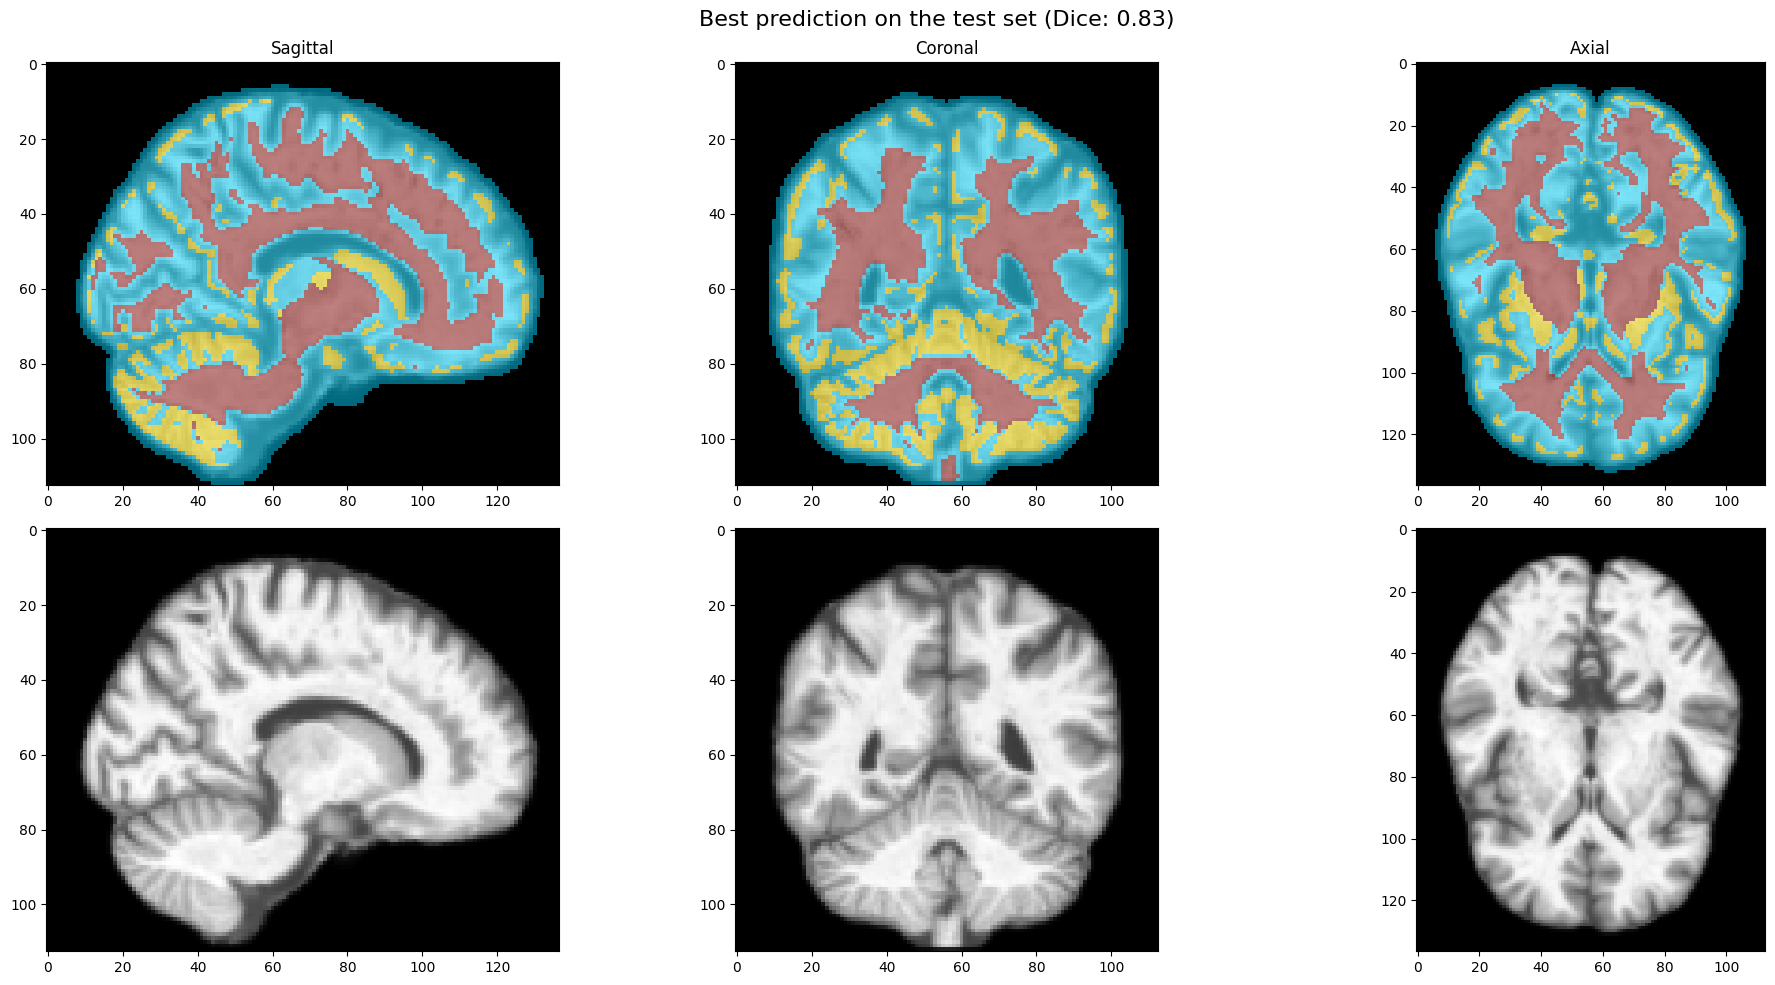

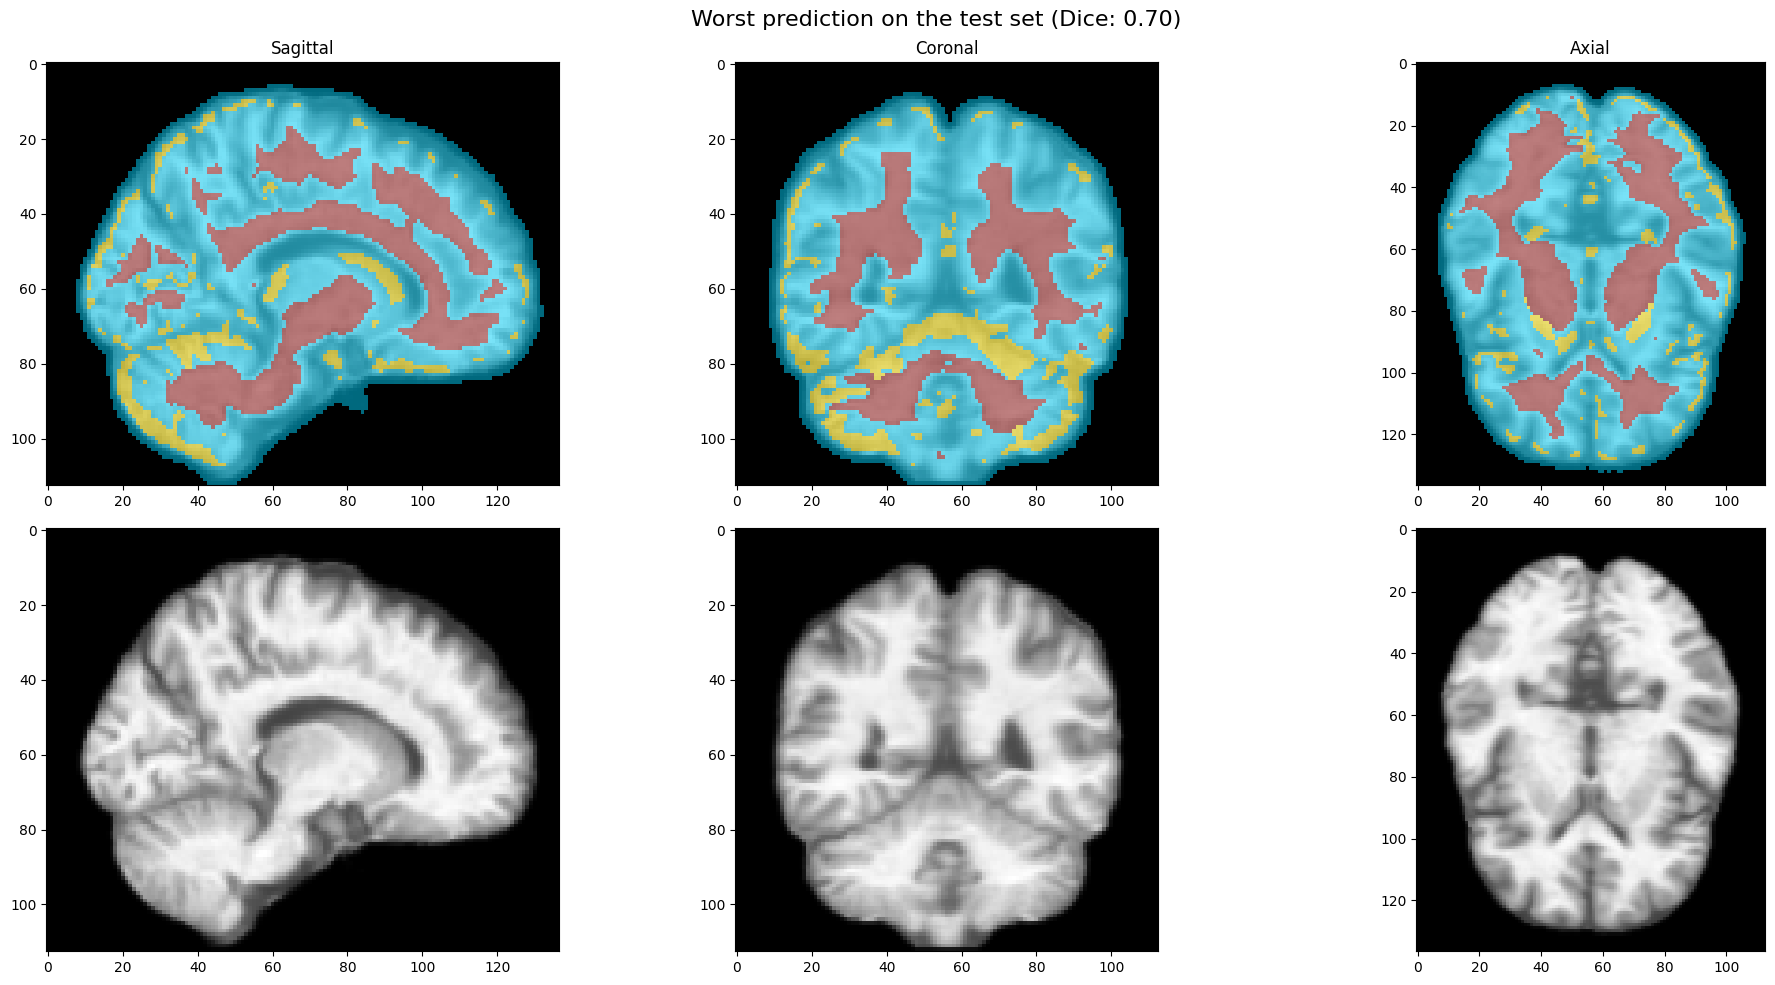

In [27]:
all_unet_preds = []
model.eval()
with torch.no_grad():
    for idx in range(len(images_test)):
        vol = torch.tensor(images_test[idx]).unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float)
        logits = model(vol)
        pred_labels = torch.argmax(logits, dim=1)[0].cpu().numpy()
        all_unet_preds.append(pred_labels)

visualize_best_and_worst_samples(predictions=all_unet_preds, ground_truth=segmentations_test, images=images_test)

# Summarize the results of all of the segmentation methods implemented.


In [28]:
def plot_results_summary(results_dict, save_prefix=None):
    metrics = ['dice', 'precision', 'recall']
    metric_labels = {'dice': 'Dice', 'precision': 'Precision', 'recall': 'Recall'}
    
    first_model = next(iter(results_dict.values()))
    tissues = list(first_model.keys())

    model_names = list(results_dict.keys())
    n_models = len(model_names)

    colors = ['#40536c', '#8da6c0']

    positions = np.arange(len(tissues))
    width = 0.8 / n_models  

    figs = []
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(8, 5))

        for i, model_name in enumerate(model_names):
            values = [float(results_dict[model_name][t][metric]) for t in tissues]
            offset = (i - (n_models - 1) / 2) * width
            bars = ax.bar(positions + offset, values, width,
                           label=model_name, color=colors[i % len(colors)],
                           edgecolor='white', linewidth=0.6)

            for rect, value in zip(bars, values):
                ax.annotate(f'{value:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                            xytext=(0, 3), textcoords='offset points',
                            ha='center', va='bottom', fontsize=9)

        ax.set_ylabel(metric_labels[metric])
        ax.set_title(f'{metric_labels[metric]} by Brain Tissue Type', fontsize=13, pad=12)
        ax.set_xticks(positions)
        ax.set_xticklabels(tissues, fontsize=11)
        ax.set_ylim(0, 1.12)               
        ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)             
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)
        ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.02, 1),
                   borderaxespad=0, frameon=False)

        fig.tight_layout()
        if save_prefix:
            fig.savefig(f'{save_prefix}_{metric}.png', dpi=150, bbox_inches='tight')
        figs.append(fig)

    plt.show()
    return figs

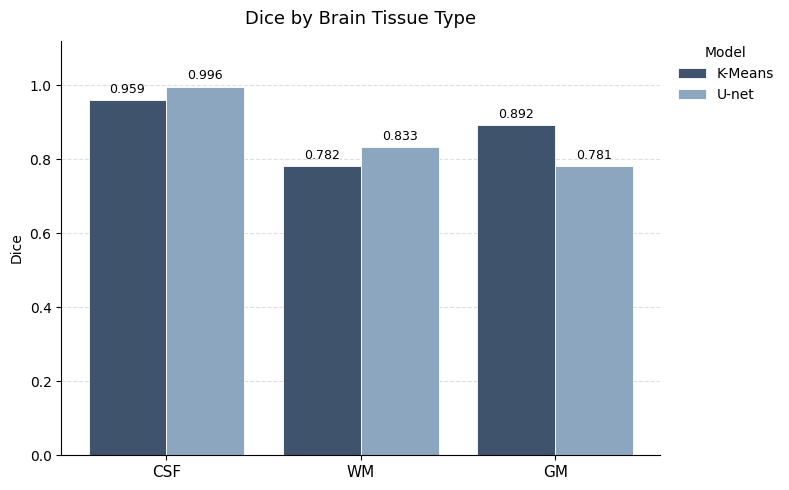

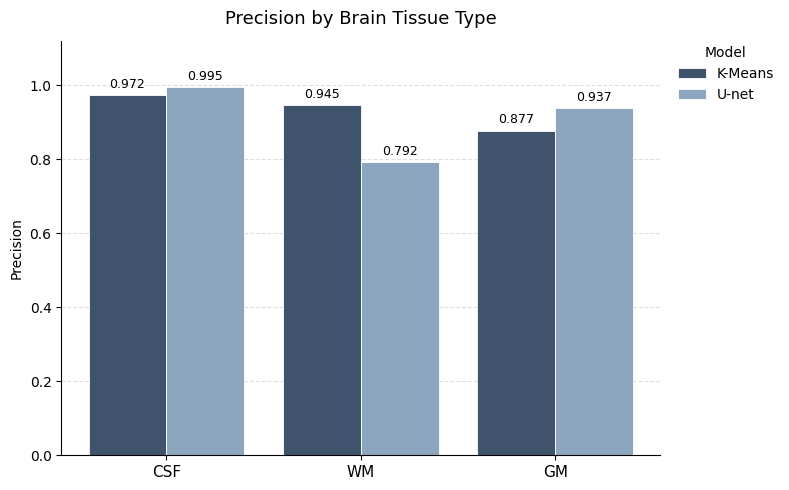

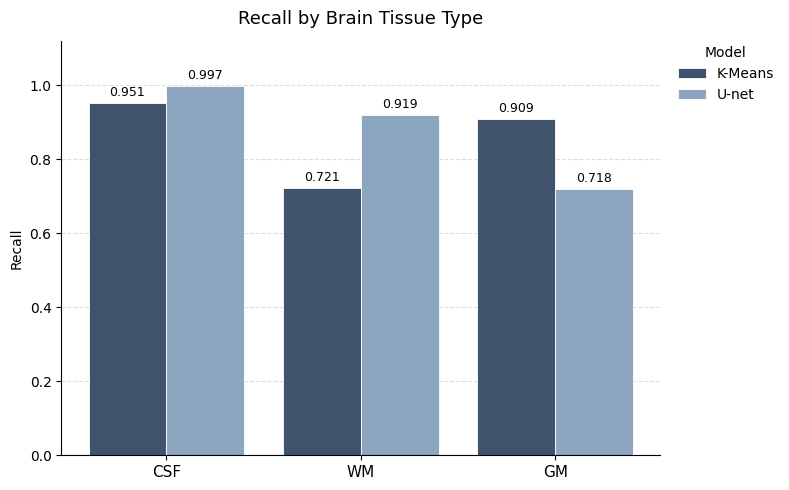

In [29]:
if __name__ == '__main__':
    sample_results = {
        'K-Means': {
            'CSF': {'dice': 0.959, 'precision': 0.972, 'recall': 0.951},
            'WM':  {'dice': 0.782, 'precision': 0.945, 'recall': 0.721},
            'GM':  {'dice': 0.892, 'precision': 0.877, 'recall': 0.909},
        },
        'U-net': {
            'CSF': {'dice': 0.996, 'precision': 0.995, 'recall': 0.997},
            'WM':  {'dice': 0.833, 'precision': 0.792, 'recall': 0.919},
            'GM':  {'dice': 0.781, 'precision': 0.937, 'recall': 0.718},
        },
    }
    plot_results_summary(sample_results)